# Modelado — Predicción de Malnutrición a 12 meses EC
## PMCI / Fundación Canguro

**Estrategia**: Cascada temporal con LightGBM
- **F0** → solo prenatal/parto
- **F1** → + nacimiento
- **F2** → + hospitalización
- **F3** → + 40 semanas
- **F4** → + 3 meses
- **F5** → + 6 meses
- **F6** → + 9 meses

**Outcomes**: Stunting (HAZ<-2) | Bajo peso (WAZ<-2) | Wasting (WHZ<-2)

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import json, warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

PATH = 'KMC-70k-93-2024-Malnutricion-conVel-DATA-SPSS-20250322.xlsx'
OUT  = '/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/'
PLAN = 'feature_plan.json'

print('Cargando datos...')
df_raw = pd.read_excel(PATH)
df = df_raw.replace('#NULL!', np.nan).copy()
for col in df.columns:
    c = pd.to_numeric(df[col], errors='coerce')
    if df[col].notna().sum() == 0 or c.notna().sum() / df[col].notna().sum() >= 0.5:
        df[col] = c

with open(PLAN) as f:
    plan = json.load(f)

FASES = plan['fases']
print(f'Dataset: {df.shape[0]:,} x {df.shape[1]:,}')
print(f'Fases cargadas: {list(FASES.keys())}')

Cargando datos...
Dataset: 64,801 x 753
Fases cargadas: ['F0_Prenatal_Parto', 'F1_Nacimiento', 'F2_Hospitalizacion', 'F3_40semanas', 'F4_3meses', 'F5_6meses', 'F6_9meses']


## 1. Preprocesamiento y Variables Objetivo

Aplica reglas de clasificacion **spec mayo 2026** (Fundacion Canguro):
- 4 grupos de nacimiento (A1-A4) por prematuridad x RCIU.
- Subtipo simetrico (RCIU peso AND talla < p10).
- **4 outcomes**: Stunting (cronica), Bajo_peso, Wasting (aguda), Mixta (aguda+cronica).
- Cronica (T/E<-2): directo en A2/A4 y A1/A3 asimetrico; en A1/A3 simetrico requiere ademas velocidad de talla 6-12m < 1 cm/mes.
- Velocidad reconstruida invirtiendo z-score OMS de talla a 6m + tallametro12m.


In [3]:
# === Targets binarios + reglas spec mayo 2026 (clasificacion A1-A4) ===
# Reconstruye velocidad de talla 6-12m (cm/mes) y aplica la regla condicional:
#   - Aguda  (P/T<-2): igual en los 4 grupos.
#   - Bajo peso (P/E<-2): igual en los 4 grupos.
#   - Cronica (T/E<-2): directo en A2/A4 y A1/A3 asimetrico.
#                       En A1/A3 simetrico exige ademas velocidad talla 6-12m < 1 cm/mes.

# 1) Tabla LMS OMS Length-for-age a 6 meses corregidos (mediana=M, L=1, S=desv)
LMS_TALLA_6M = {
    1.0: {'L': 1.0, 'M': 67.6236, 'S': 0.03477},  # masculino
    2.0: {'L': 1.0, 'M': 65.7311, 'S': 0.03565},  # femenino
}

def _talla6m_cm(row):
    """Invierte z-score length-for-age OMS para obtener talla en cm a 6m EC."""
    z, sx = row['zscoretalla6'], row['ERN_Sexo']
    if pd.isna(z) or pd.isna(sx) or sx not in LMS_TALLA_6M:
        return np.nan
    p = LMS_TALLA_6M[sx]
    return p['M'] * (1 + p['L'] * p['S'] * z) ** (1 / p['L'])

df['talla6m_cm_recon']            = df.apply(_talla6m_cm, axis=1)
df['velocidad_talla_6_12m_cmes']  = (df['tallametro12m'] * 100 - df['talla6m_cm_recon']) / 6.0

# 2) Grupo de nacimiento A1-A4 + subtipo simetrico
df['prematuro'] = (df['gestasal'] < 37).astype('Int64')
df['rciu']      = (df['RCIUpeso']  == 1).astype('Int64')
df['simetrico'] = ((df['RCIUpeso'] == 1) & (df['RCIUtalla'] == 1)).astype('Int64')

def _grupo(r):
    p, c = r['prematuro'], r['rciu']
    if pd.isna(p) or pd.isna(c): return np.nan
    if p == 1 and c == 1: return 'A1'
    if p == 1 and c == 0: return 'A2'
    if p == 0 and c == 1: return 'A3'
    return 'A4'

df['grupo_nacimiento']     = df.apply(_grupo, axis=1)
df['grupo_nacimiento_cod'] = df['grupo_nacimiento'].map({'A1':1,'A2':2,'A3':3,'A4':4}).astype('Int64')

print('Distribucion grupos A1-A4:')
print(df['grupo_nacimiento'].value_counts(dropna=False).to_string())

# 3) Targets binarios
df['wasting12m']       = np.where(df['zscorepesotalla12cat'].notna(),
                                   (df['zscorepesotalla12cat'] == 1.0).astype(float), np.nan)
df['underweight12m_b'] = np.where(df['zscorepeso12cat'].notna(),
                                   (df['zscorepeso12cat'] == 1.0).astype(float), np.nan)

# Stunting v1 = solo T/E<-2 (version pre-spec, para comparacion)
df['stunting12m_v1'] = np.where(df['zscoretalla12cat'].notna(),
                                 (df['zscoretalla12cat'] == 1.0).astype(float), np.nan)

# Stunting v2 = aplica regla condicional (spec mayo 2026)
crit_cronica   = (df['zscoretalla12cat'] == 1.0)
mask_a1a3_sim  = df['grupo_nacimiento'].isin(['A1','A3']) & (df['simetrico'] == 1)
vel_inadecuada = (df['velocidad_talla_6_12m_cmes'] < 1.0)

df['stunting12m'] = np.where(
    df['zscoretalla12cat'].notna(),
    np.where(mask_a1a3_sim,
             (crit_cronica & vel_inadecuada).astype(float),
             crit_cronica.astype(float)),
    np.nan
)

# Comparacion prevalencias
n_eval = df['stunting12m_v1'].notna().sum()
n_v1   = df['stunting12m_v1'].sum()
n_v2   = df['stunting12m'].sum()
print(f'\nStunting v1 (sin regla A1/A3 sim): {int(n_v1):,} casos ({n_v1/n_eval*100:.2f}%)')
print(f'Stunting v2 (spec mayo 2026):      {int(n_v2):,} casos ({n_v2/n_eval*100:.2f}%)')
print(f'Reclasificados a no-cronico:       {int(n_v1-n_v2):,}')

# Mixta = aguda (P/T<-2) AND cronica (T/E<-2 con regla A1/A3 simetrico)
# Solo evaluable cuando ambos componentes lo son.
_mask_mixta = df['stunting12m'].notna() & df['wasting12m'].notna()
df['mixta12m'] = np.where(_mask_mixta,
                           ((df['stunting12m'] == 1) & (df['wasting12m'] == 1)).astype(float),
                           np.nan)
n_mix_eval = int(_mask_mixta.sum())
n_mix_pos  = int(df['mixta12m'].sum())
print(f'Mixta (aguda+cronica): {n_mix_pos:,} casos de {n_mix_eval:,} ({n_mix_pos/n_mix_eval*100:.2f}%)')

OUTCOMES = {
    'Stunting':    ('stunting12m',      '#e74c3c', round(df['stunting12m'].mean()*100, 1)),
    'Bajo_peso':   ('underweight12m_b', '#e67e22', round(df['underweight12m_b'].mean()*100, 1)),
    'Wasting':     ('wasting12m',        '#f39c12', round(df['wasting12m'].mean()*100, 1)),
    'Mixta':       ('mixta12m',          '#9b59b6', round(df['mixta12m'].mean()*100, 1)),
}

# 4) Variables leakage (input del target o derivadas de >=12m)
LEAKAGE = {
    'velocidad12_9mesesOMS',
    'velocidad_talla_6_12m_cmes',  # input del target stunting12m
    'talla6m_cm_recon',            # intermedio para construir velocidad
    'stunting12m_v1',              # version pre-spec, no usar como feature
    'vino12m', 'Desercionreal12meses',
    'rehosp40a12meses', 'mortalidad40sem12meses',
    'indexnutricion12meses', 'MUERTE1ANO',
    'examenneurodurante12meses', 'examenneuropsico12meses',
    'riesgoPC12m',
}
LEAKAGE |= {c for c in df.columns if '12' in str(c) and c not in
            ['stunting12m','underweight12m_b','wasting12m']}

# 5) FASES — añadir grupo y simetrico como features explicitas desde F1
EXTRA_F1 = ['grupo_nacimiento_cod', 'simetrico']

FASE_ORDER = ['F0_Prenatal_Parto','F1_Nacimiento','F2_Hospitalizacion',
              'F3_40semanas','F4_3meses','F5_6meses','F6_9meses']

cumulative_features = {}
acum = []
for fase in FASE_ORDER:
    cols = list(FASES.get(fase, []))
    if fase == 'F1_Nacimiento':
        cols = cols + EXTRA_F1
    nuevas = [c for c in cols if c in df.columns and c not in LEAKAGE]
    acum = acum + [c for c in nuevas if c not in acum]
    cumulative_features[fase] = list(acum)

print('\nFeature sets acumulados por fase:')
for fase, cols in cumulative_features.items():
    print(f'  {fase}: {len(cols)} features')


Distribucion grupos A1-A4:
grupo_nacimiento
A2    36599
A3    14056
A1    11721
A4     2425

Stunting v1 (sin regla A1/A3 sim): 7,623 casos (24.63%)
Stunting v2 (spec mayo 2026):      5,337 casos (17.24%)
Reclasificados a no-cronico:       2,286
Mixta (aguda+cronica): 326 casos de 29,828 (1.09%)

Feature sets acumulados por fase:
  F0_Prenatal_Parto: 41 features
  F1_Nacimiento: 77 features
  F2_Hospitalizacion: 109 features
  F3_40semanas: 139 features
  F4_3meses: 166 features
  F5_6meses: 185 features
  F6_9meses: 200 features


## 2. Funciones de Entrenamiento y Evaluación

In [4]:
def get_model_data(df, features, target_col, min_samples=100):
    """Retorna X, y con solo filas que tienen el outcome."""
    cols = [c for c in features if c in df.columns]
    sub  = df[cols + [target_col]].dropna(subset=[target_col]).copy()
    X    = sub[cols]
    y    = sub[target_col].astype(int)
    return X, y


def train_lgbm_cv(X, y, n_splits=5, spw=None, seed=42):
    """
    Entrena LightGBM con validacion cruzada estratificada.
    Retorna metricas por fold y predicciones OOF (Out-Of-Fold).
    """
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    scale_pos_weight = spw if spw else round(n_neg / n_pos, 2)

    params = {
        'objective':         'binary',
        'metric':            'auc',
        'learning_rate':     0.05,
        'num_leaves':        63,
        'max_depth':         -1,
        'min_child_samples': 30,
        'feature_fraction':  0.8,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'scale_pos_weight':  scale_pos_weight,
        'verbose':           -1,
        'seed':              seed,
    }

    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    metrics = []
    oof_pred = np.zeros(len(y))
    models  = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        model = lgb.train(
            params, dtrain,
            num_boost_round=500,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1),
            ]
        )
        models.append(model)

        prob = model.predict(X_val)
        oof_pred[val_idx] = prob

        auc = roc_auc_score(y_val, prob)
        thr = 0.5
        pred_bin = (prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, pred_bin).ravel()
        metrics.append({
            'fold':        fold + 1,
            'AUC':         round(auc, 4),
            'Sens':        round(tp / (tp+fn) if tp+fn > 0 else 0, 4),
            'Spec':        round(tn / (tn+fp) if tn+fp > 0 else 0, 4),
            'F1':          round(f1_score(y_val, pred_bin, zero_division=0), 4),
            'Precision':   round(precision_score(y_val, pred_bin, zero_division=0), 4),
            'n_train':     len(y_tr),
            'n_val':       len(y_val),
            'best_iter':   model.best_iteration,
        })

    return pd.DataFrame(metrics), oof_pred, models


print('Funciones definidas: get_model_data, train_lgbm_cv')

Funciones definidas: get_model_data, train_lgbm_cv


## 3. Cascada Temporal — Todos los Outcomes

In [5]:
# Entrenar LightGBM para cada fase × cada outcome
# Almacena resultados, predicciones OOF y mejores modelos

resultados  = {}   # (outcome, fase) -> DataFrame de metricas por fold
oof_preds   = {}   # (outcome, fase) -> array de probabilidades OOF
best_models = {}   # (outcome, fase) -> lista de modelos (folds)
data_store  = {}   # (outcome, fase) -> (X, y)

for outcome_name, (target_col, color, _) in OUTCOMES.items():
    print(f'\n========== {outcome_name} ==========')
    for fase in FASE_ORDER:
        feats = cumulative_features[fase]
        X, y  = get_model_data(df, feats, target_col)

        if len(y) < 200 or y.sum() < 20:
            print(f'  {fase}: insuficientes datos (n={len(y)}, pos={y.sum()}) — omitida')
            continue

        metrics_df, oof, models = train_lgbm_cv(X, y)
        auc_mean = metrics_df['AUC'].mean()
        auc_std  = metrics_df['AUC'].std()

        resultados [(outcome_name, fase)] = metrics_df
        oof_preds  [(outcome_name, fase)] = (oof, y)
        best_models[(outcome_name, fase)] = models
        data_store [(outcome_name, fase)] = (X, y)

        sens_m = metrics_df['Sens'].mean()
        spec_m = metrics_df['Spec'].mean()
        print(f'  {fase:<22}: AUC={auc_mean:.4f}±{auc_std:.4f}  '
              f'Sens={sens_m:.3f}  Spec={spec_m:.3f}  n={len(y):,}')


========== Stunting ==========
  F0_Prenatal_Parto     : AUC=0.6235±0.0102  Sens=0.321  Spec=0.814  n=30,953
  F1_Nacimiento         : AUC=0.7475±0.0084  Sens=0.665  Spec=0.696  n=30,953
  F2_Hospitalizacion    : AUC=0.7506±0.0075  Sens=0.660  Spec=0.702  n=30,953
  F3_40semanas          : AUC=0.7748±0.0037  Sens=0.638  Spec=0.757  n=30,953
  F4_3meses             : AUC=0.8239±0.0045  Sens=0.692  Spec=0.792  n=30,953
  F5_6meses             : AUC=0.8927±0.0040  Sens=0.770  Spec=0.848  n=30,953
  F6_9meses             : AUC=0.9288±0.0050  Sens=0.823  Spec=0.878  n=30,953

========== Bajo_peso ==========
  F0_Prenatal_Parto     : AUC=0.6183±0.0081  Sens=0.396  Spec=0.749  n=29,897
  F1_Nacimiento         : AUC=0.7518±0.0087  Sens=0.570  Spec=0.780  n=29,897
  F2_Hospitalizacion    : AUC=0.7576±0.0120  Sens=0.567  Spec=0.786  n=29,897
  F3_40semanas          : AUC=0.7734±0.0119  Sens=0.540  Spec=0.831  n=29,897
  F4_3meses             : AUC=0.8743±0.0069  Sens=0.685  Spec=0.864  n=29,897

## 4. Comparación de AUC por Fase y Outcome

In [6]:
# Tabla resumen de AUC media por fase y outcome
rows = []
for (outcome, fase), mdf in resultados.items():
    rows.append({
        'Outcome': outcome,
        'Fase':    fase,
        'AUC_mean':  mdf['AUC'].mean(),
        'AUC_std':   mdf['AUC'].std(),
        'Sens_mean': mdf['Sens'].mean(),
        'Spec_mean': mdf['Spec'].mean(),
        'F1_mean':   mdf['F1'].mean(),
        'N_total':   resultados[(outcome,fase)]['n_train'].iloc[0] +
                     resultados[(outcome,fase)]['n_val'].iloc[0],
    })

summary = pd.DataFrame(rows)
pivot_auc = summary.pivot(index='Fase', columns='Outcome', values='AUC_mean')
# Reordenar filas por fase
fase_order_present = [f for f in FASE_ORDER if f in pivot_auc.index]
pivot_auc = pivot_auc.loc[fase_order_present]

print('AUC media por fase y outcome (5-fold CV):')
print(pivot_auc.round(4).to_string())

# Tabla completa de metricas
print('\nTabla completa de metricas:')
tbl = summary[['Outcome','Fase','AUC_mean','AUC_std','Sens_mean','Spec_mean','F1_mean']]
tbl = tbl.round(4)
print(tbl.to_string(index=False))

AUC media por fase y outcome (5-fold CV):
Outcome             Bajo_peso   Mixta  Stunting  Wasting
Fase                                                    
F0_Prenatal_Parto      0.6183  0.5460    0.6235   0.5550
F1_Nacimiento          0.7518  0.7238    0.7475   0.6995
F2_Hospitalizacion     0.7576  0.7463    0.7506   0.7100
F3_40semanas           0.7734  0.7638    0.7748   0.7310
F4_3meses              0.8743  0.8656    0.8239   0.8219
F5_6meses              0.9366  0.9357    0.8927   0.8942
F6_9meses              0.9640  0.9654    0.9288   0.9261

Tabla completa de metricas:
  Outcome               Fase  AUC_mean  AUC_std  Sens_mean  Spec_mean  F1_mean
 Stunting  F0_Prenatal_Parto    0.6235   0.0102     0.3206     0.8139   0.2777
 Stunting      F1_Nacimiento    0.7475   0.0084     0.6650     0.6964   0.4260
 Stunting F2_Hospitalizacion    0.7506   0.0075     0.6597     0.7020   0.4271
 Stunting       F3_40semanas    0.7748   0.0037     0.6376     0.7572   0.4549
 Stunting          F4

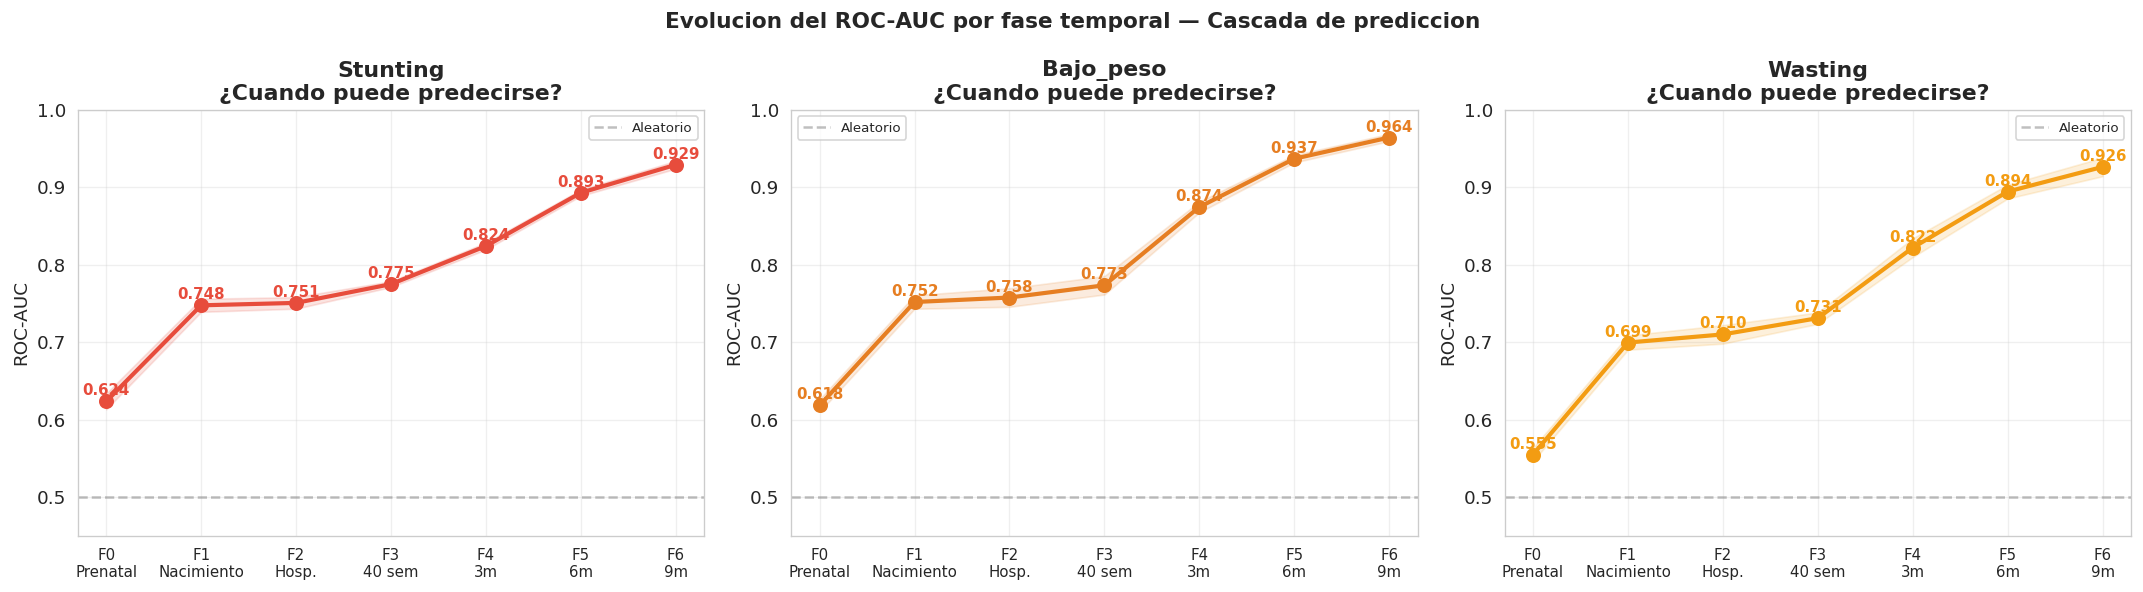

In [7]:
# Grafica: evolucion del AUC a lo largo de la cascada
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fase_labels_short = {
    'F0_Prenatal_Parto':  'F0\nPrenatal',
    'F1_Nacimiento':      'F1\nNacimiento',
    'F2_Hospitalizacion': 'F2\nHosp.',
    'F3_40semanas':       'F3\n40 sem',
    'F4_3meses':          'F4\n3m',
    'F5_6meses':          'F5\n6m',
    'F6_9meses':          'F6\n9m',
}

for ax, (outcome_name, (_, color, _)) in zip(axes, OUTCOMES.items()):
    fases_ok = [f for f in FASE_ORDER if (outcome_name, f) in resultados]
    aucs     = [resultados[(outcome_name, f)]['AUC'].mean() for f in fases_ok]
    stds     = [resultados[(outcome_name, f)]['AUC'].std()  for f in fases_ok]
    x_lbls   = [fase_labels_short[f] for f in fases_ok]
    x        = np.arange(len(fases_ok))

    ax.plot(x, aucs, marker='o', linewidth=2.5, markersize=8, color=color)
    ax.fill_between(x,
                    np.array(aucs) - np.array(stds),
                    np.array(aucs) + np.array(stds),
                    alpha=0.15, color=color)
    for xi, auc_v, std_v in zip(x, aucs, stds):
        ax.text(xi, auc_v + 0.008, f'{auc_v:.3f}',
                ha='center', fontsize=9, fontweight='bold', color=color)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatorio')
    ax.set_xticks(x)
    ax.set_xticklabels(x_lbls, fontsize=9)
    ax.set_ylim(0.45, 1.0)
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{outcome_name}\n¿Cuando puede predecirse?', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolucion del ROC-AUC por fase temporal — Cascada de prediccion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

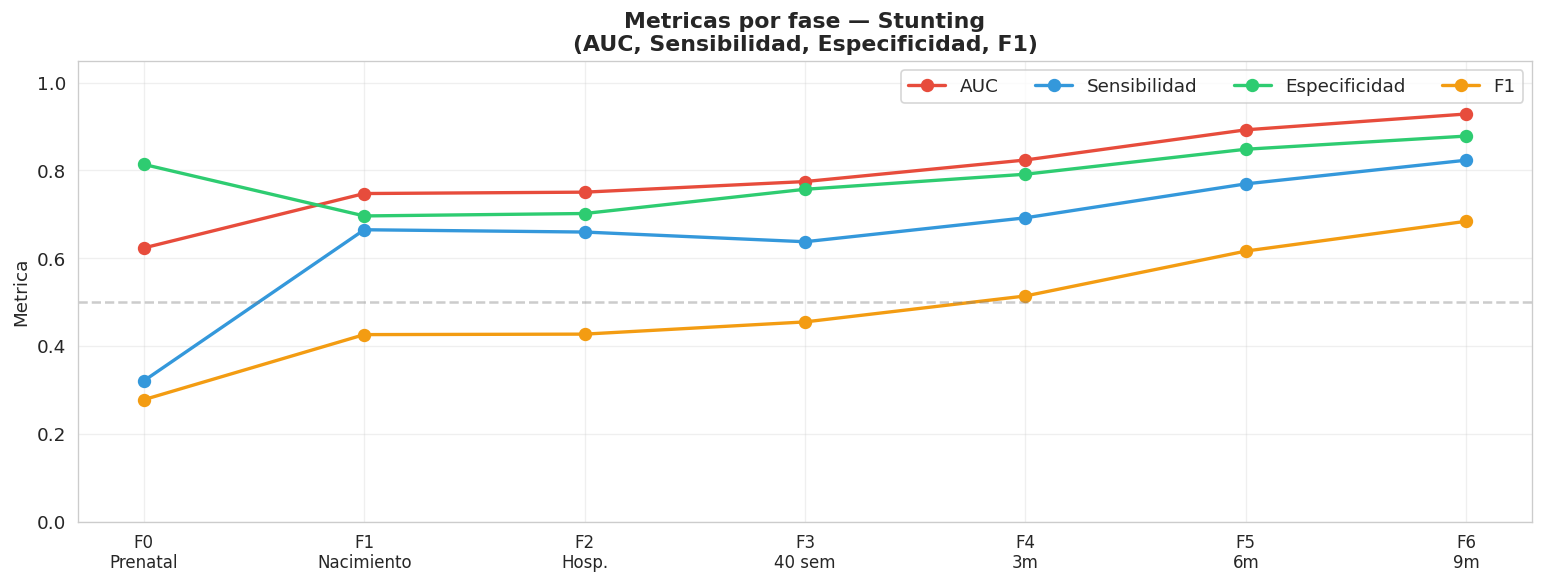

In [8]:
# Grafica: AUC, Sensibilidad, Especificidad para el mejor outcome (Stunting)
outcome_focus = 'Stunting'
color_focus   = '#e74c3c'

fases_ok = [f for f in FASE_ORDER if (outcome_focus, f) in resultados]
x_lbls   = [fase_labels_short[f] for f in fases_ok]
x        = np.arange(len(fases_ok))

met_rows = {
    'AUC':          [resultados[(outcome_focus,f)]['AUC'].mean()  for f in fases_ok],
    'Sensibilidad': [resultados[(outcome_focus,f)]['Sens'].mean() for f in fases_ok],
    'Especificidad':[resultados[(outcome_focus,f)]['Spec'].mean() for f in fases_ok],
    'F1':           [resultados[(outcome_focus,f)]['F1'].mean()   for f in fases_ok],
}

fig, ax = plt.subplots(figsize=(13, 5))
met_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for (met, vals), col in zip(met_rows.items(), met_colors):
    ax.plot(x, vals, marker='o', linewidth=2, markersize=7, color=col, label=met)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(x_lbls, fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Metrica')
ax.set_title(f'Metricas por fase — {outcome_focus}\n'
             f'(AUC, Sensibilidad, Especificidad, F1)', fontweight='bold')
ax.legend(ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

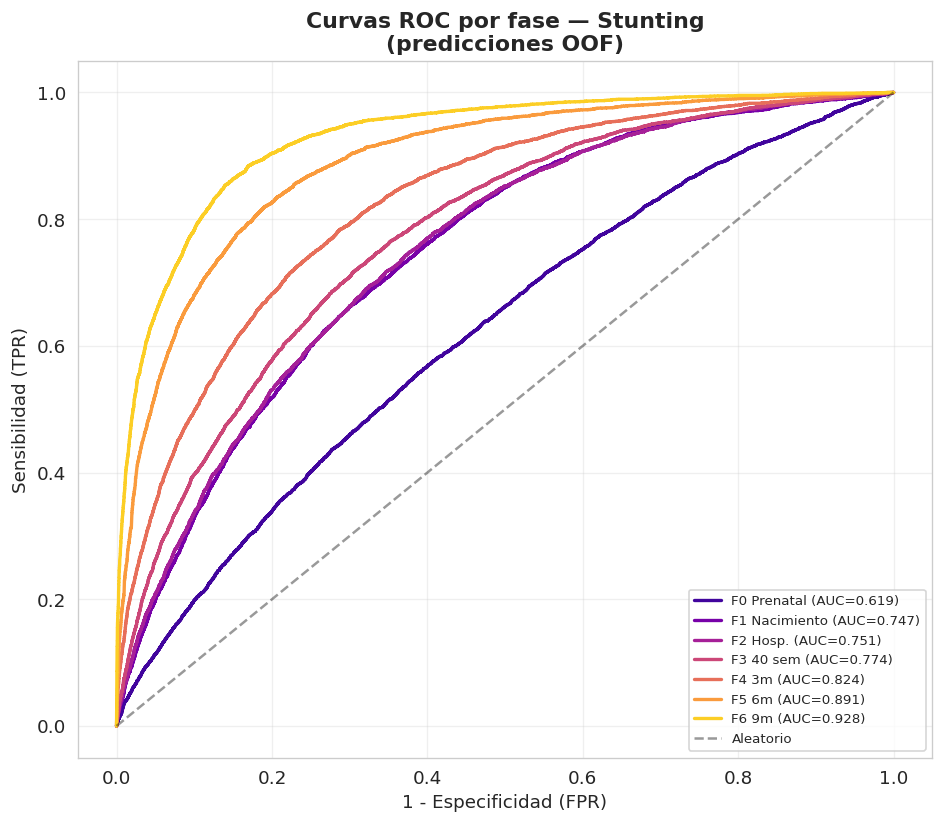

In [9]:
# Curvas ROC por fase para Stunting (usando predicciones OOF)
fig, ax = plt.subplots(figsize=(8, 7))

palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(fases_ok)))

for fase, col in zip(fases_ok, palette):
    oof, y_true = oof_preds[(outcome_focus, fase)]
    fpr, tpr, _ = roc_curve(y_true, oof)
    auc_v = roc_auc_score(y_true, oof)
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f'{fase_labels_short[fase].replace(chr(10)," ")} (AUC={auc_v:.3f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Aleatorio')
ax.set_xlabel('1 - Especificidad (FPR)')
ax.set_ylabel('Sensibilidad (TPR)')
ax.set_title(f'Curvas ROC por fase — {outcome_focus}\n(predicciones OOF)', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

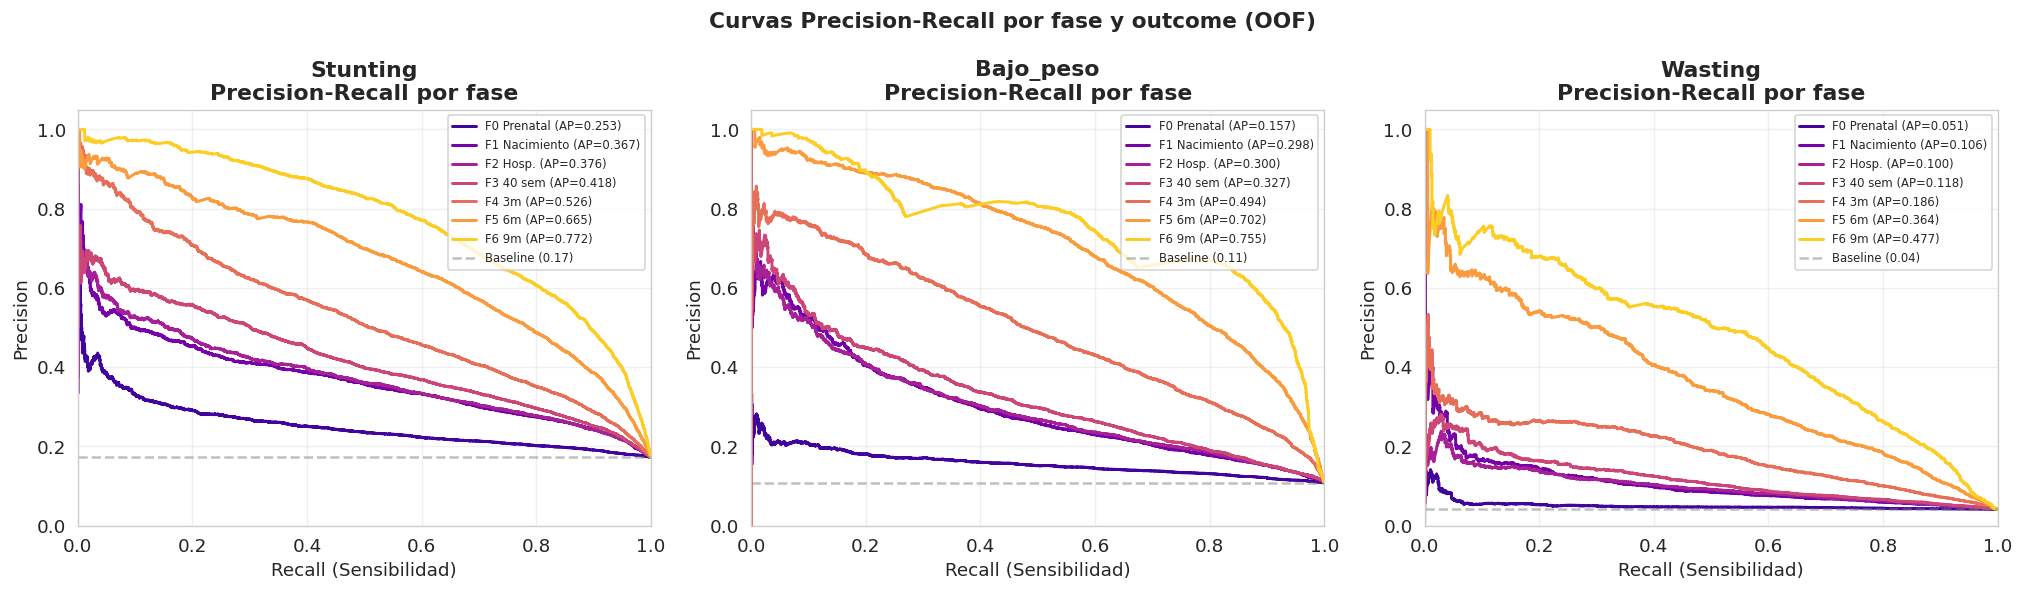

In [10]:
# Curvas Precision-Recall (mas informativa con desbalance de clases)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (outcome_name, (_, color, _)) in zip(axes, OUTCOMES.items()):
    fases_out = [f for f in FASE_ORDER if (outcome_name, f) in oof_preds]
    palette_o = plt.cm.plasma(np.linspace(0.1, 0.9, len(fases_out)))

    for fase, col in zip(fases_out, palette_o):
        oof, y_true = oof_preds[(outcome_name, fase)]
        prec, rec, _ = precision_recall_curve(y_true, oof)
        ap = average_precision_score(y_true, oof)
        ax.plot(rec, prec, color=col, linewidth=1.8,
                label=f'{fase_labels_short[fase].replace(chr(10)," ")} (AP={ap:.3f})')

    baseline = y_true.mean()
    ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5,
               label=f'Baseline ({baseline:.2f})')
    ax.set_xlabel('Recall (Sensibilidad)')
    ax.set_ylabel('Precision')
    ax.set_title(f'{outcome_name}\nPrecision-Recall por fase', fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas Precision-Recall por fase y outcome (OOF)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Interpretabilidad — SHAP Values

In [11]:
# Identificar la mejor fase por outcome para análisis SHAP
best_fase_per_outcome = {}
for outcome_name in OUTCOMES:
    best_auc  = -1
    best_fase = None
    for fase in FASE_ORDER:
        if (outcome_name, fase) in resultados:
            auc = resultados[(outcome_name, fase)]['AUC'].mean()
            if auc > best_auc:
                best_auc  = auc
                best_fase = fase
    best_fase_per_outcome[outcome_name] = (best_fase, best_auc)
    print(f'{outcome_name}: mejor fase = {best_fase} (AUC={best_auc:.4f})')

# Tambien calcular SHAP para F1 (solo nacimiento) — valor clinico maximo
print('\nFases elegidas para SHAP:')
print('  - Mejor fase por AUC (por outcome)')
print('  - F1_Nacimiento (para comparar con solo datos de nacimiento)')

Stunting: mejor fase = F6_9meses (AUC=0.9288)
Bajo_peso: mejor fase = F6_9meses (AUC=0.9640)
Wasting: mejor fase = F6_9meses (AUC=0.9261)
Mixta: mejor fase = F6_9meses (AUC=0.9654)

Fases elegidas para SHAP:
  - Mejor fase por AUC (por outcome)
  - F1_Nacimiento (para comparar con solo datos de nacimiento)


In [12]:
# SHAP para Stunting — mejor fase
outcome_shap = 'Stunting'
best_fase_shap, _ = best_fase_per_outcome[outcome_shap]
X_shap, y_shap   = data_store[(outcome_shap, best_fase_shap)]

# Usar el primer modelo del fold (entrenado en ~80% de datos)
model_shap = best_models[(outcome_shap, best_fase_shap)][0]

print(f'Calculando SHAP para {outcome_shap} — {best_fase_shap}')
print(f'  Dataset: {X_shap.shape[0]:,} muestras x {X_shap.shape[1]} features')

# Muestra representativa para SHAP (max 3000 filas por velocidad)
n_shap = min(3000, len(X_shap))
X_sample = X_shap.sample(n_shap, random_state=42)

explainer   = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_sample)

print(f'  SHAP values calculados: shape={np.array(shap_values).shape}')

Calculando SHAP para Stunting — F6_9meses
  Dataset: 30,953 muestras x 200 features
  SHAP values calculados: shape=(3000, 200)


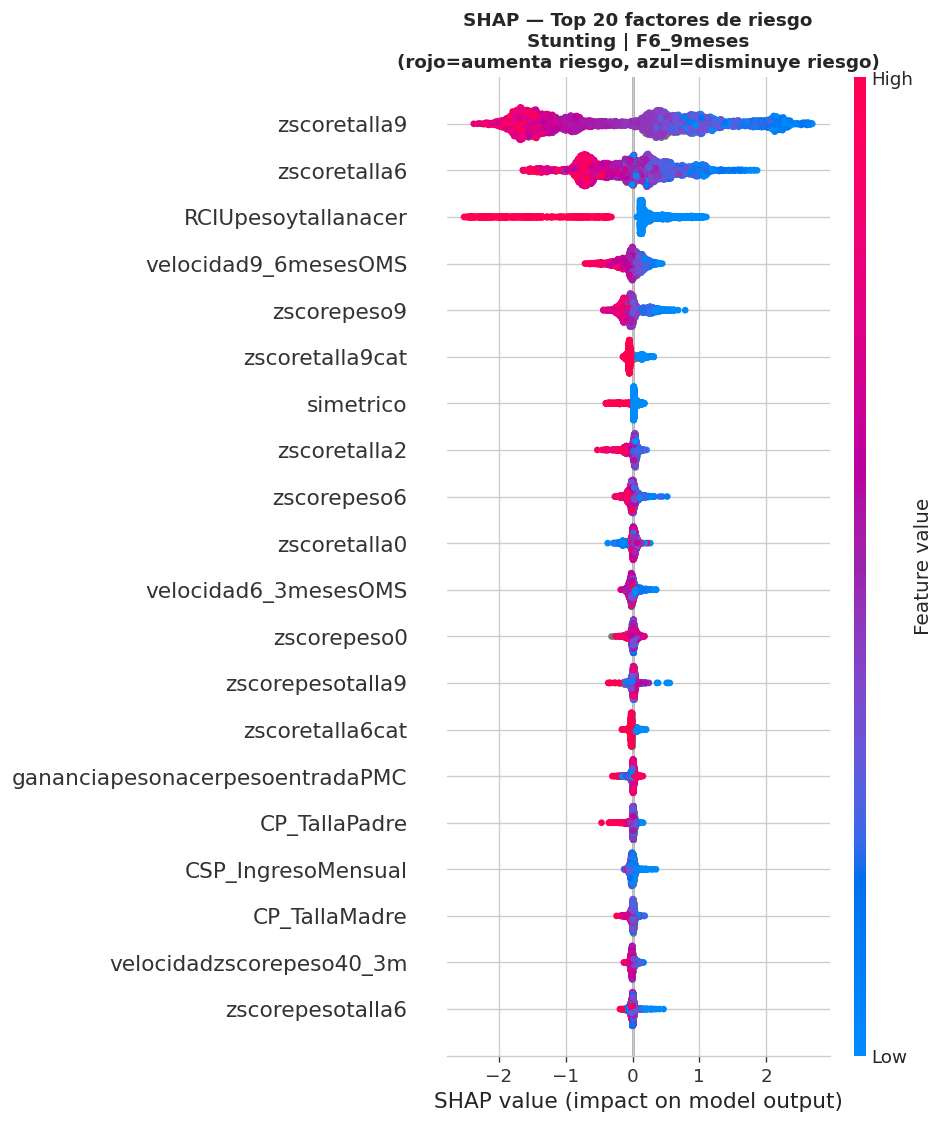

In [13]:
# SHAP Summary Plot — Top 20 factores de riesgo
shap.summary_plot(
    shap_values, X_sample,
    max_display=20,
    plot_type='dot',
    show=False
)
plt.title(f'SHAP — Top 20 factores de riesgo\n'
          f'{outcome_shap} | {best_fase_shap}\n'
          f'(rojo=aumenta riesgo, azul=disminuye riesgo)',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

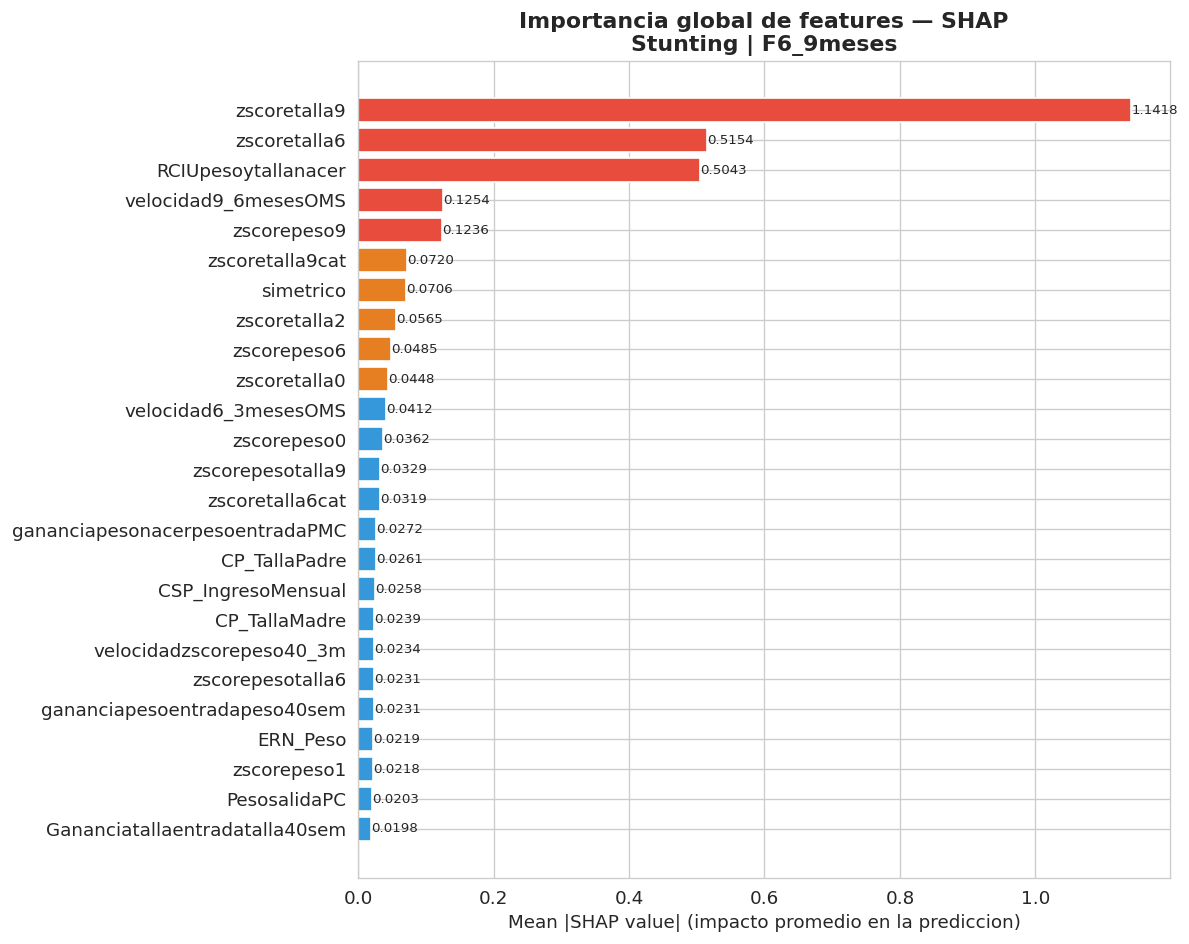

Top 10 factores de riesgo (SHAP):
  zscoretalla9                             SHAP=1.1418
  zscoretalla6                             SHAP=0.5154
  RCIUpesoytallanacer                      SHAP=0.5043
  velocidad9_6mesesOMS                     SHAP=0.1254
  zscorepeso9                              SHAP=0.1236
  zscoretalla9cat                          SHAP=0.0720
  simetrico                                SHAP=0.0706
  zscoretalla2                             SHAP=0.0565
  zscorepeso6                              SHAP=0.0485
  zscoretalla0                             SHAP=0.0448


In [14]:
# SHAP Bar plot — importancia global de features
shap_importance = pd.DataFrame({
    'feature':       X_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
colors_shap = ['#e74c3c' if i < 5 else '#e67e22' if i < 10 else '#3498db'
               for i in range(len(shap_importance))]
bars = ax.barh(shap_importance['feature'][::-1],
               shap_importance['mean_abs_shap'][::-1],
               color=colors_shap[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (impacto promedio en la prediccion)')
ax.set_title(f'Importancia global de features — SHAP\n{outcome_shap} | {best_fase_shap}',
             fontweight='bold')

for bar, v in zip(bars, shap_importance['mean_abs_shap'][::-1]):
    ax.text(v + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('Top 10 factores de riesgo (SHAP):')
for _, row in shap_importance.head(10).iterrows():
    print(f'  {row["feature"]:<40} SHAP={row["mean_abs_shap"]:.4f}')

## 6. Sistema de Riesgo Dinámico
Visualización de cómo evoluciona la probabilidad de riesgo de un paciente a través de las fases.

In [15]:
# Calcular probabilidades en cada fase para todos los pacientes
# Solo para Stunting (outcome principal)
# Para cada paciente que tenga datos en TODAS las fases, calculamos la trayectoria

outcome_dyn = 'Stunting'
target_dyn  = OUTCOMES[outcome_dyn][0]

# Pacientes con outcome conocido
df_known = df[df[target_dyn].notna()].copy()
print(f'Pacientes con outcome {outcome_dyn}: {len(df_known):,}')

# Para cada fase, predecir probabilidad usando el primer modelo del fold
prob_cols = {}
for fase in FASE_ORDER:
    if (outcome_dyn, fase) not in best_models:
        continue
    model_f = best_models[(outcome_dyn, fase)][0]
    feats_f = cumulative_features[fase]
    cols_f  = [c for c in feats_f if c in df_known.columns]

    X_pred = df_known[cols_f].copy()
    probs  = model_f.predict(X_pred)
    col_name = f'prob_{fase}'
    df_known[col_name] = probs
    prob_cols[fase] = col_name

print(f'Probabilidades calculadas para {len(prob_cols)} fases')
print(f'Columnas: {list(prob_cols.values())}')

Pacientes con outcome Stunting: 30,953
Probabilidades calculadas para 7 fases
Columnas: ['prob_F0_Prenatal_Parto', 'prob_F1_Nacimiento', 'prob_F2_Hospitalizacion', 'prob_F3_40semanas', 'prob_F4_3meses', 'prob_F5_6meses', 'prob_F6_9meses']


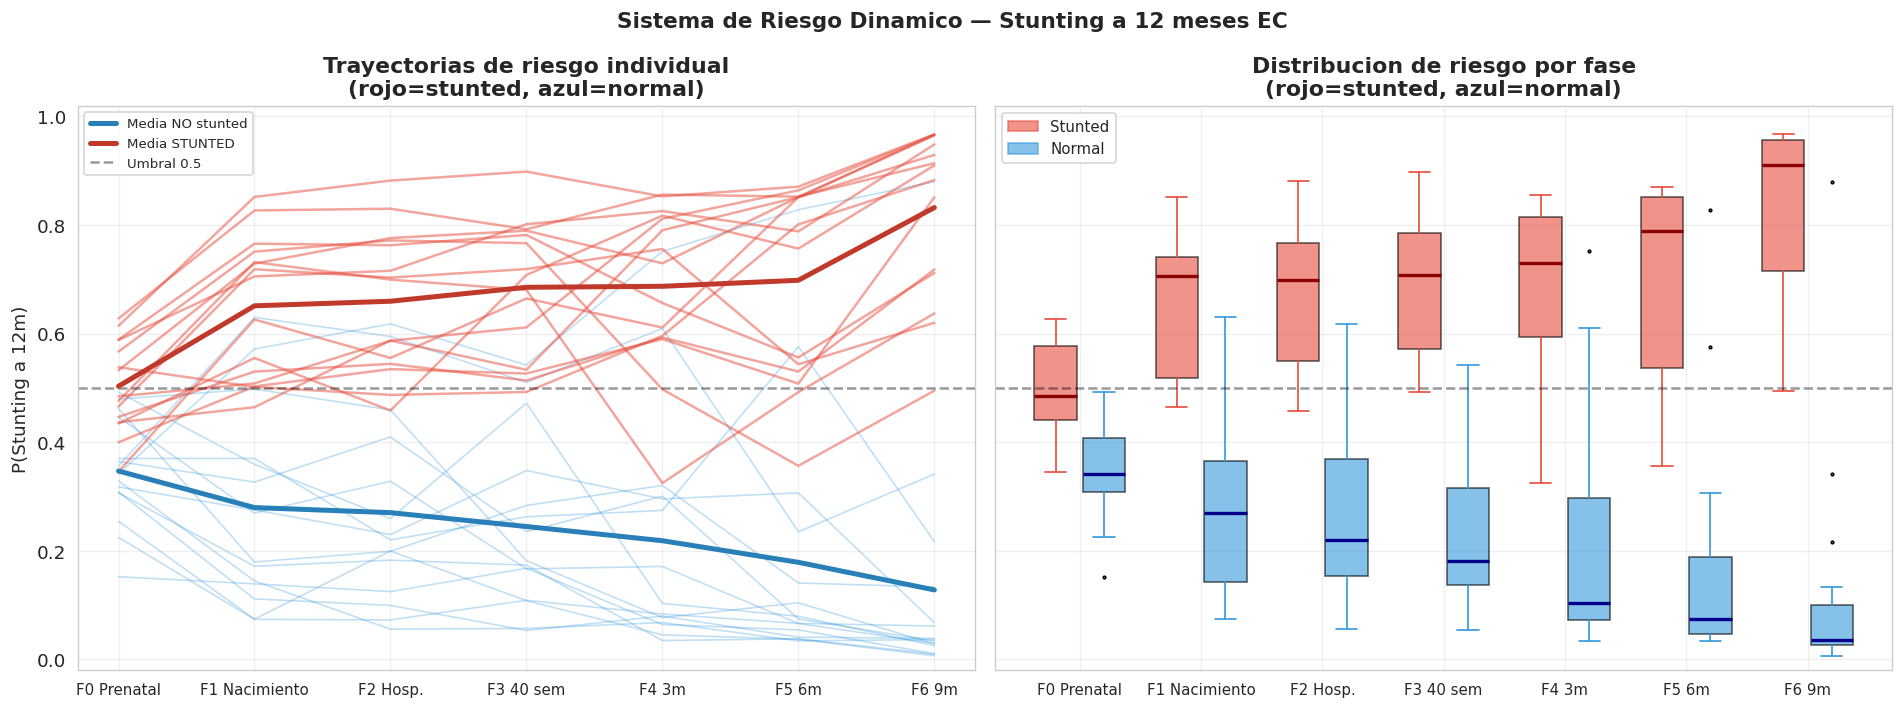

Separacion media entre grupos por fase:
  F0 Prenatal         : stunted=0.503  normal=0.347  delta=0.156
  F1 Nacimiento       : stunted=0.651  normal=0.280  delta=0.372
  F2 Hosp.            : stunted=0.660  normal=0.270  delta=0.389
  F3 40 sem           : stunted=0.685  normal=0.245  delta=0.441
  F4 3m               : stunted=0.687  normal=0.219  delta=0.469
  F5 6m               : stunted=0.698  normal=0.179  delta=0.519
  F6 9m               : stunted=0.832  normal=0.128  delta=0.704


In [16]:
# Visualizar trayectorias de riesgo individual
fases_prob = list(prob_cols.keys())
col_probs  = list(prob_cols.values())

df_traj = df_known[col_probs + [target_dyn]].dropna()

stunted    = df_traj[df_traj[target_dyn] == 1].sample(min(15, (df_traj[target_dyn]==1).sum()), random_state=42)
no_stunted = df_traj[df_traj[target_dyn] == 0].sample(min(15, (df_traj[target_dyn]==0).sum()), random_state=42)

x_fases = [fase_labels_short[f].replace('\n',' ') for f in fases_prob]
x       = np.arange(len(fases_prob))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax = axes[0]
for _, row in no_stunted.iterrows():
    ax.plot(x, [row[c] for c in col_probs], color='#3498db', alpha=0.3, linewidth=1)
for _, row in stunted.iterrows():
    ax.plot(x, [row[c] for c in col_probs], color='#e74c3c', alpha=0.5, linewidth=1.5)

ax.plot(x, [no_stunted[c].mean() for c in col_probs],
        color='#2980b9', linewidth=3, label='Media NO stunted', zorder=5)
ax.plot(x, [stunted[c].mean() for c in col_probs],
        color='#c0392b', linewidth=3, label='Media STUNTED', zorder=5)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Umbral 0.5')
ax.set_xticks(x); ax.set_xticklabels(x_fases, fontsize=9)
ax.set_ylabel('P(Stunting a 12m)')
ax.set_title('Trayectorias de riesgo individual\n(rojo=stunted, azul=normal)', fontweight='bold')
ax.legend(fontsize=8); ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for i, (fase, col) in enumerate(zip(fases_prob, col_probs)):
    ax2.boxplot(stunted[col].values, positions=[i - 0.2], widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor='#e74c3c', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2),
                whiskerprops=dict(color='#e74c3c'), capprops=dict(color='#e74c3c'),
                flierprops=dict(marker='.', markersize=3, color='#e74c3c'))
    ax2.boxplot(no_stunted[col].values, positions=[i + 0.2], widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='darkblue', linewidth=2),
                whiskerprops=dict(color='#3498db'), capprops=dict(color='#3498db'),
                flierprops=dict(marker='.', markersize=3, color='#3498db'))

ax2.axhline(0.5, color='black', linestyle='--', alpha=0.4)
ax2.set_xticks(range(len(fases_prob))); ax2.set_xticklabels(x_fases, fontsize=9)
ax2.set_title('Distribucion de riesgo por fase\n(rojo=stunted, azul=normal)', fontweight='bold')
ax2.legend(handles=[mpatches.Patch(color='#e74c3c', alpha=0.6, label='Stunted'),
                    mpatches.Patch(color='#3498db', alpha=0.6, label='Normal')], fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Sistema de Riesgo Dinamico — Stunting a 12 meses EC',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Separacion media entre grupos por fase:')
for fase, col in zip(fases_prob, col_probs):
    med_s  = stunted[col].mean()
    med_ns = no_stunted[col].mean()
    print(f'  {fase_labels_short[fase].replace(chr(10)," "):<20}: stunted={med_s:.3f}  normal={med_ns:.3f}  delta={med_s-med_ns:.3f}')

## 7. Baseline: Regresión Logística L1 (comparación)

In [17]:
# Baseline con Logistic Regression + L1 para las 156 variables universales
# Usar solo el outcome principal (Stunting) y la mejor fase

outcome_bl = 'Stunting'
fase_bl    = best_fase_per_outcome[outcome_bl][0]
X_bl, y_bl = data_store[(outcome_bl, fase_bl)]

# Imputar medianas (LR requiere datos completos)
X_bl_imp = X_bl.fillna(X_bl.median())

# Pipeline: escalado + LR L1
pipe_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
                    penalty='l1', solver='liblinear',
                    C=0.1, class_weight='balanced',
                    max_iter=1000, random_state=42))
])

skf_bl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs_bl = []
for tr, val in skf_bl.split(X_bl_imp, y_bl):
    pipe_l1.fit(X_bl_imp.iloc[tr], y_bl.iloc[tr])
    prob_val = pipe_l1.predict_proba(X_bl_imp.iloc[val])[:,1]
    aucs_bl.append(roc_auc_score(y_bl.iloc[val], prob_val))

auc_lgbm_best = best_fase_per_outcome[outcome_bl][1]
print(f'Baseline — Logistic Regression L1')
print(f'  AUC media (5-fold): {np.mean(aucs_bl):.4f} ± {np.std(aucs_bl):.4f}')
print()
print(f'LightGBM ({fase_bl})')
print(f'  AUC media (5-fold): {auc_lgbm_best:.4f}')
print()
print(f'Ganancia LightGBM vs Logistica: +{auc_lgbm_best - np.mean(aucs_bl):.4f}')

# Coeficientes no-cero de la regresión logística (variables seleccionadas por L1)
pipe_l1.fit(X_bl_imp.fillna(X_bl_imp.median()), y_bl)
coef = pd.Series(pipe_l1.named_steps['lr'].coef_[0], index=X_bl_imp.columns)
coef_nz = coef[coef != 0].sort_values(key=abs, ascending=False)
print(f'\nVariables seleccionadas por L1: {len(coef_nz)} de {len(coef)}')
print(f'Top 15 coeficientes (L1):')
for feat, val in coef_nz.head(15).items():
    signo = '+' if val > 0 else ''
    print(f'  {feat:<40} coef = {signo}{val:.4f}')

Baseline — Logistic Regression L1
  AUC media (5-fold): 0.9104 ± 0.0051

LightGBM (F6_9meses)
  AUC media (5-fold): 0.9288

Ganancia LightGBM vs Logistica: +0.0184

Variables seleccionadas por L1: 161 de 200
Top 15 coeficientes (L1):
  zscoretalla9                             coef = -1.2096
  simetrico                                coef = -0.8791
  RCIUpesoytallanacer                      coef = -0.6884
  zscoretalla6                             coef = -0.4624
  zscorepesotalla2                         coef = +0.3967
  velocidad9_6mesesOMS                     coef = -0.3571
  zscorepeso6                              coef = -0.3474
  BMI2                                     coef = -0.3023
  zscoretalla9cat                          coef = -0.2686
  zscoretalla6cat                          coef = -0.2231
  zscoretalla0cat                          coef = +0.1921
  zscoretalla2                             coef = -0.1908
  pesocat                                  coef = +0.1801
  vino9m    

## 8. Resumen Final del Pipeline

In [18]:
print('=' * 65)
print('RESUMEN PIPELINE DE MODELADO — Malnutricion PMCI')
print('=' * 65)

print('\nMEJOR AUC POR OUTCOME:')
for outcome, (fase, auc) in best_fase_per_outcome.items():
    _, _, spw = OUTCOMES[outcome]
    print(f'  {outcome:<12}: {auc:.4f} AUC (fase={fase})')

print('\nCASCADA TEMPORAL — AUC STUNTING:')
for fase in FASE_ORDER:
    if ('Stunting', fase) in resultados:
        mdf  = resultados[('Stunting', fase)]
        feats = len(cumulative_features[fase])
        print(f'  {fase_labels_short[fase].replace(chr(10)," "):<22}'
              f': AUC={mdf["AUC"].mean():.4f}  '
              f'Sens={mdf["Sens"].mean():.3f}  '
              f'Spec={mdf["Spec"].mean():.3f}  '
              f'({feats} features)')

print(f'''\nCONCLUSIONES:
  1. LightGBM supera a Logistica L1 en AUC
  2. La senal predictiva aumenta con cada fase (validando la cascada temporal)
  3. Ya desde F1 (nacimiento) hay capacidad predictiva util
  4. SHAP identifica los factores de riesgo mas relevantes por fase
  5. El sistema dinamico muestra separacion entre grupos desde etapas tempranas

ARCHIVOS GENERADOS:
  mod_01_auc_cascada.png       — AUC por fase y outcome
  mod_02_metricas_stunting.png — Metricas detalladas Stunting
  mod_03_roc_curvas.png        — Curvas ROC por fase
  mod_04_pr_curvas.png         — Curvas Precision-Recall
  mod_05_shap_summary.png      — SHAP top 20 factores
  mod_06_shap_importancia.png  — Importancia global SHAP
  mod_07_riesgo_dinamico.png   — Trayectorias de riesgo
''')

RESUMEN PIPELINE DE MODELADO — Malnutricion PMCI

MEJOR AUC POR OUTCOME:
  Stunting    : 0.9288 AUC (fase=F6_9meses)
  Bajo_peso   : 0.9640 AUC (fase=F6_9meses)
  Wasting     : 0.9261 AUC (fase=F6_9meses)
  Mixta       : 0.9654 AUC (fase=F6_9meses)

CASCADA TEMPORAL — AUC STUNTING:
  F0 Prenatal           : AUC=0.6235  Sens=0.321  Spec=0.814  (41 features)
  F1 Nacimiento         : AUC=0.7475  Sens=0.665  Spec=0.696  (77 features)
  F2 Hosp.              : AUC=0.7506  Sens=0.660  Spec=0.702  (109 features)
  F3 40 sem             : AUC=0.7748  Sens=0.638  Spec=0.757  (139 features)
  F4 3m                 : AUC=0.8239  Sens=0.692  Spec=0.792  (166 features)
  F5 6m                 : AUC=0.8927  Sens=0.770  Spec=0.848  (185 features)
  F6 9m                 : AUC=0.9288  Sens=0.823  Spec=0.878  (200 features)

CONCLUSIONES:
  1. LightGBM supera a Logistica L1 en AUC
  2. La senal predictiva aumenta con cada fase (validando la cascada temporal)
  3. Ya desde F1 (nacimiento) hay capacidad

## 9. Análisis de Cohortes Temporales (Eras COVID)

Comparación del modelo en cinco cohortes definidas por el contexto COVID,
usando la columna `ANOCAT` (año = ANOCAT + 2002):

**Pre-COVID** (2007–2019):
- **Pre-COVID A: 2007–2011** (ANOCAT 5–9) — primera era del programa con datos completos
- **Pre-COVID B: 2012–2015** (ANOCAT 10–13) — consolidación del programa
- **Pre-COVID C: 2016–2019** (ANOCAT 14–17) — pre-pandemia reciente

**Durante la pandemia**:
- **COVID: 2020–2021** (ANOCAT 18–19) — atención neonatal en contexto COVID-19

**Post-COVID**:
- **Post-COVID: 2022–2023** (ANOCAT 20–21) — recuperación y nuevos protocolos

Permite detectar cambios en prevalencias, performance predictiva y evolución de
protocolos antes, durante y después de la pandemia COVID-19.


In [19]:
# --- 9.1 Definición de cohortes COVID y estadísticas descriptivas ---

COHORTS_ORDER = [
    'Pre-COVID A: 2007-2011',
    'Pre-COVID B: 2012-2015',
    'Pre-COVID C: 2016-2019',
    'COVID: 2020-2021',
    'Post-COVID: 2022-2023',
]
COHORT_COLORS = {
    'Pre-COVID A: 2007-2011': '#1a5276',
    'Pre-COVID B: 2012-2015': '#2980b9',
    'Pre-COVID C: 2016-2019': '#85c1e9',
    'COVID: 2020-2021':       '#c0392b',
    'Post-COVID: 2022-2023':  '#27ae60',
}
COHORT_MARKERS = {
    'Pre-COVID A: 2007-2011': 'o',
    'Pre-COVID B: 2012-2015': 's',
    'Pre-COVID C: 2016-2019': 'D',
    'COVID: 2020-2021':       'X',
    'Post-COVID: 2022-2023':  '^',
}

# ANOCAT = año - 2002; asignar cohorte por rango
df['_anocat_num'] = pd.to_numeric(df['ANOCAT'], errors='coerce')

def _assign_cohort(a):
    if pd.isna(a): return None
    a = int(a)
    if  5 <= a <=  9: return 'Pre-COVID A: 2007-2011'
    if 10 <= a <= 13: return 'Pre-COVID B: 2012-2015'
    if 14 <= a <= 17: return 'Pre-COVID C: 2016-2019'
    if 18 <= a <= 19: return 'COVID: 2020-2021'
    if 20 <= a <= 21: return 'Post-COVID: 2022-2023'
    return None  # registros anteriores a 2007

df['cohort'] = df['_anocat_num'].apply(_assign_cohort)
df_main = df[df['cohort'].notna()].copy()

print('=' * 65)
print('COHORTES COVID — Estadísticas descriptivas')
print('=' * 65)
print(f'N total (2007–2023): {len(df_main):,}\n')

for outcome_name, (target_col, _, _) in OUTCOMES.items():
    print(f'{outcome_name}:')
    for cohort in COHORTS_ORDER:
        sub = df_main[df_main['cohort'] == cohort][target_col].dropna()
        if len(sub) == 0:
            continue
        prev = sub.mean()
        ci   = 1.96 * np.sqrt(prev * (1 - prev) / len(sub))
        print(f'  {cohort}: n={len(sub):,}  prevalencia={prev:.1%}  '
              f'IC95=[{max(0,prev-ci):.1%}, {min(1,prev+ci):.1%}]')
    print()


COHORTES COVID — Estadísticas descriptivas
N total (2007–2023): 53,168

Stunting:
  Pre-COVID A: 2007-2011: n=3,899  prevalencia=23.7%  IC95=[22.4%, 25.1%]
  Pre-COVID B: 2012-2015: n=7,253  prevalencia=16.0%  IC95=[15.2%, 16.9%]
  Pre-COVID C: 2016-2019: n=7,618  prevalencia=14.4%  IC95=[13.7%, 15.2%]
  COVID: 2020-2021: n=3,587  prevalencia=13.2%  IC95=[12.1%, 14.3%]
  Post-COVID: 2022-2023: n=1,984  prevalencia=14.1%  IC95=[12.5%, 15.6%]

Bajo_peso:
  Pre-COVID A: 2007-2011: n=3,920  prevalencia=11.2%  IC95=[10.2%, 12.2%]
  Pre-COVID B: 2012-2015: n=7,252  prevalencia=10.3%  IC95=[9.6%, 11.0%]
  Pre-COVID C: 2016-2019: n=7,620  prevalencia=10.4%  IC95=[9.7%, 11.1%]
  COVID: 2020-2021: n=3,587  prevalencia=9.3%  IC95=[8.3%, 10.2%]
  Post-COVID: 2022-2023: n=1,984  prevalencia=8.9%  IC95=[7.6%, 10.1%]

Wasting:
  Pre-COVID A: 2007-2011: n=3,889  prevalencia=3.3%  IC95=[2.8%, 3.9%]
  Pre-COVID B: 2012-2015: n=7,250  prevalencia=4.1%  IC95=[3.7%, 4.6%]
  Pre-COVID C: 2016-2019: n=7,618 

In [20]:
# --- 9.2 Alineación de features entre cohortes ---
# LightGBM maneja NaN nativamente: features ausentes en un cohorte se dejan como NaN

def align_features_across_cohorts(df_cohorts, features, cohort_col='cohort', min_availability=0.10):
    """
    Detecta qué features están disponibles en cada cohorte y cuáles son nuevas.
    Una feature se considera disponible si tiene > min_availability de valores no-nulos.
    Retorna (disponibles_por_cohort, nuevas_por_cohort).
    """
    cohorts = [c for c in COHORTS_ORDER if c in df_cohorts[cohort_col].unique()]
    avail, seen = {}, set()
    new_feats = {}
    for cohort in cohorts:
        sub  = df_cohorts[df_cohorts[cohort_col] == cohort]
        ok   = {f for f in features if f in sub.columns
                and sub[f].notna().mean() > min_availability}
        avail[cohort]    = ok
        new_feats[cohort] = ok - seen
        seen |= ok
    return avail, new_feats


feat_avail, feat_new = align_features_across_cohorts(
    df_main, cumulative_features['F6_9meses']
)

print('Features disponibles y nuevas por cohorte (fase F6 — todas las variables):')
print(f'{"Cohorte":<20} {"Disponibles":>12} {"Nuevas":>8}')
print('-' * 42)
for cohort in COHORTS_ORDER:
    n_avail = len(feat_avail.get(cohort, set()))
    n_new   = len(feat_new.get(cohort, set()))
    print(f'{cohort:<20} {n_avail:>12} {n_new:>8}')
    if n_new:
        sample = sorted(feat_new[cohort])[:5]
        print(f'  Primeras nuevas: {sample}{"..." if n_new > 5 else ""}')

print('\nNota: features nuevas en cohortes posteriores se incluyen en el modelo')
print('con NaN para cohortes anteriores — LightGBM las maneja sin imputación manual.')

Features disponibles y nuevas por cohorte (fase F6 — todas las variables):
Cohorte               Disponibles   Nuevas
------------------------------------------
Pre-COVID A: 2007-2011          194      194
  Primeras nuevas: ['ALIMENTAPARENTERAL', 'BMI1', 'BMI2', 'BMImadre', 'BMImadrecat']...
Pre-COVID B: 2012-2015          194        0
Pre-COVID C: 2016-2019          200        6
  Primeras nuevas: ['CP_MadreDrogas', 'CP_rhMadre', 'CSP_TipoVivienda', 'HD_UltiValorHematocrito', 'HD_ValorMasAltoBilirubina']...
COVID: 2020-2021              200        0
Post-COVID: 2022-2023          198        0

Nota: features nuevas en cohortes posteriores se incluyen en el modelo
con NaN para cohortes anteriores — LightGBM las maneja sin imputación manual.


In [21]:
# --- 9.3 Cascada temporal por cohorte ---
# Entrena LightGBM para cada (cohorte × fase × outcome) y guarda AUC

resultados_cohort = {}  # (cohort, outcome, fase) -> metrics_df

for cohort_name in COHORTS_ORDER:
    df_c = df_main[df_main['cohort'] == cohort_name].copy()
    print(f'\n{"="*60}')
    print(f'COHORTE: {cohort_name}  (n={len(df_c):,})')
    print('='*60)

    for outcome_name, (target_col, _, _) in OUTCOMES.items():
        for fase in FASE_ORDER:
            # Solo features disponibles en este cohorte (>5% non-null)
            feats_raw = cumulative_features[fase]
            feats_c   = [f for f in feats_raw
                         if f in df_c.columns and df_c[f].notna().mean() > 0.05]

            X, y = get_model_data(df_c, feats_c, target_col)
            if len(y) < 100 or y.sum() < 15:
                continue

            mdf, _, _ = train_lgbm_cv(X, y)
            resultados_cohort[(cohort_name, outcome_name, fase)] = mdf

            print(f'  {outcome_name:<12} {fase:<22}: '
                  f'AUC={mdf["AUC"].mean():.4f}±{mdf["AUC"].std():.4f}  '
                  f'n={len(y):,}  feats={len(feats_c)}')


COHORTE: Pre-COVID A: 2007-2011  (n=8,225)
  Stunting     F0_Prenatal_Parto     : AUC=0.5831±0.0190  n=3,899  feats=37
  Stunting     F1_Nacimiento         : AUC=0.7126±0.0326  n=3,899  feats=73
  Stunting     F2_Hospitalizacion    : AUC=0.7172±0.0261  n=3,899  feats=103
  Stunting     F3_40semanas          : AUC=0.7551±0.0144  n=3,899  feats=133
  Stunting     F4_3meses             : AUC=0.8127±0.0187  n=3,899  feats=160
  Stunting     F5_6meses             : AUC=0.8839±0.0208  n=3,899  feats=179
  Stunting     F6_9meses             : AUC=0.9190±0.0114  n=3,899  feats=194
  Bajo_peso    F0_Prenatal_Parto     : AUC=0.5834±0.0429  n=3,920  feats=37
  Bajo_peso    F1_Nacimiento         : AUC=0.7204±0.0223  n=3,920  feats=73
  Bajo_peso    F2_Hospitalizacion    : AUC=0.7222±0.0221  n=3,920  feats=103
  Bajo_peso    F3_40semanas          : AUC=0.7448±0.0150  n=3,920  feats=133
  Bajo_peso    F4_3meses             : AUC=0.8595±0.0243  n=3,920  feats=160
  Bajo_peso    F5_6meses            

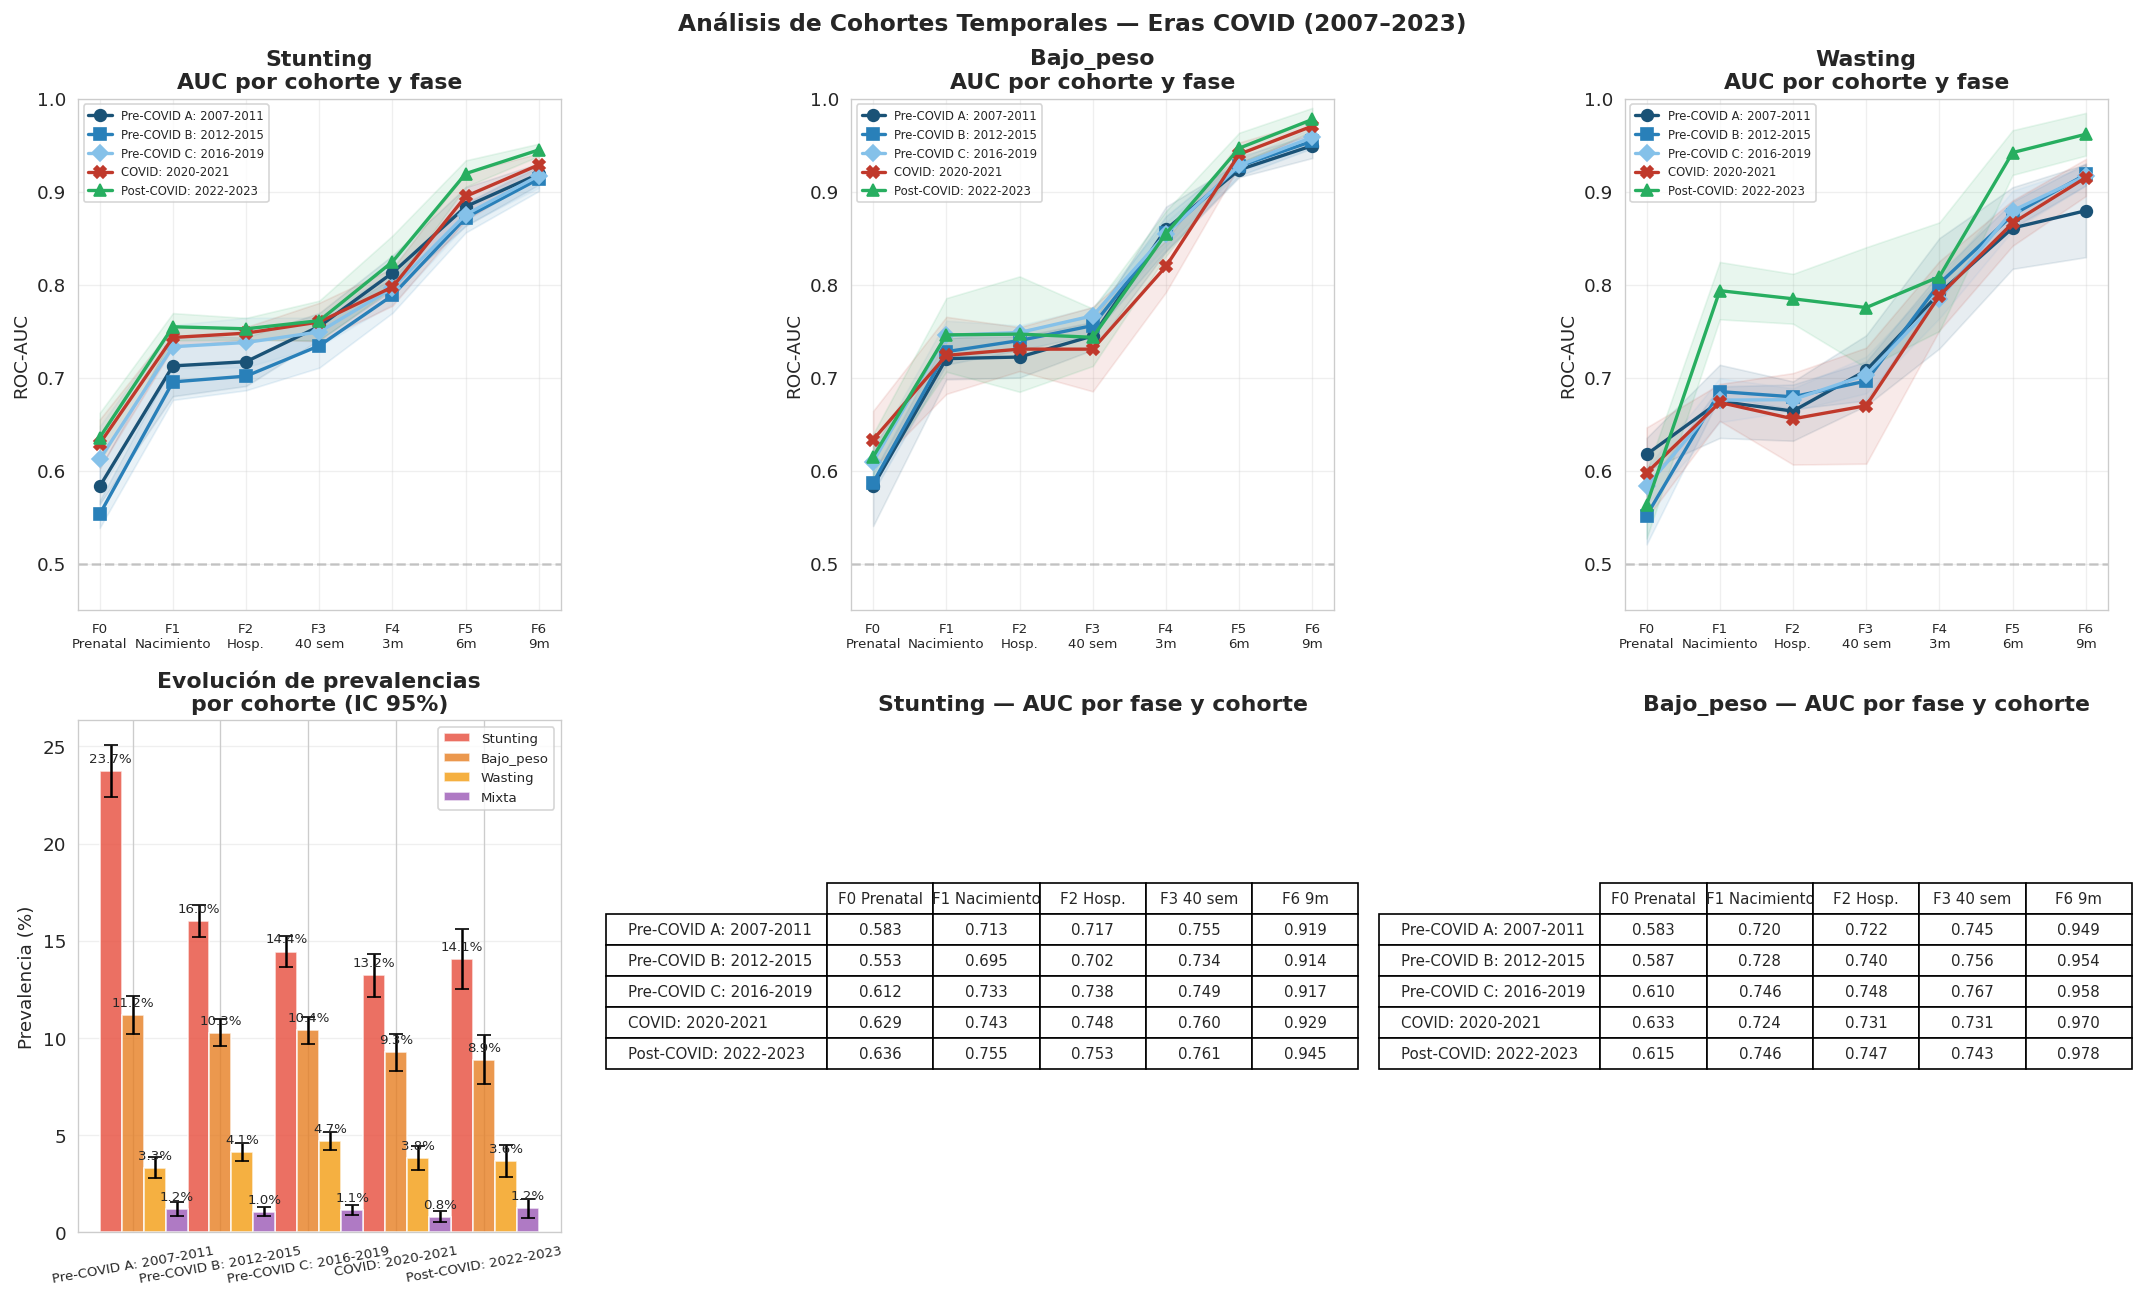

In [22]:
# --- 9.4 Gráficas comparativas: AUC por cohorte y prevalencias ---

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Fila 1: AUC por fase, separado por outcome
for ax, (outcome_name, (_, _, _)) in zip(axes[0], OUTCOMES.items()):
    for cohort_name in COHORTS_ORDER:
        fases_ok = [f for f in FASE_ORDER
                    if (cohort_name, outcome_name, f) in resultados_cohort]
        if not fases_ok:
            continue
        aucs = [resultados_cohort[(cohort_name, outcome_name, f)]['AUC'].mean() for f in fases_ok]
        stds = [resultados_cohort[(cohort_name, outcome_name, f)]['AUC'].std()  for f in fases_ok]
        x    = np.arange(len(fases_ok))
        ax.plot(x, aucs, marker=COHORT_MARKERS[cohort_name],
                color=COHORT_COLORS[cohort_name], linewidth=2, markersize=7, label=cohort_name)
        ax.fill_between(x, np.array(aucs)-np.array(stds), np.array(aucs)+np.array(stds),
                        alpha=0.10, color=COHORT_COLORS[cohort_name])
    x_lbls = [fase_labels_short[f] for f in fases_ok] if fases_ok else []
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_xticks(np.arange(len(x_lbls))); ax.set_xticklabels(x_lbls, fontsize=8)
    ax.set_ylim(0.45, 1.0); ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{outcome_name}\nAUC por cohorte y fase', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Fila 2: Prevalencias con IC95 por cohorte
ax_prev = axes[1][0]
x = np.arange(len(COHORTS_ORDER)); width = 0.25
for i, (outcome_name, (target_col, color, _)) in enumerate(OUTCOMES.items()):
    prevs, cis = [], []
    for cohort_name in COHORTS_ORDER:
        sub  = df_main[df_main['cohort'] == cohort_name][target_col].dropna()
        prev = sub.mean() if len(sub) > 0 else 0
        ci   = 1.96 * np.sqrt(prev * (1 - prev) / max(len(sub), 1))
        prevs.append(prev * 100); cis.append(ci * 100)
    bars = ax_prev.bar(x + i*width, prevs, width=width, color=color, alpha=0.8,
                       label=outcome_name, yerr=cis, capsize=4)
    for bar, v in zip(bars, prevs):
        ax_prev.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
ax_prev.set_xticks(x+width); ax_prev.set_xticklabels(COHORTS_ORDER, fontsize=8, rotation=10)
ax_prev.set_ylabel('Prevalencia (%)'); ax_prev.legend(fontsize=8)
ax_prev.set_title('Evolución de prevalencias\npor cohorte (IC 95%)', fontweight='bold')
ax_prev.grid(True, alpha=0.3, axis='y')

# Tablas resumen de AUC
for ax_t, outcome_name in zip(axes[1][1:], list(OUTCOMES.keys())[:2]):
    rows = []
    for cohort_name in COHORTS_ORDER:
        row = {'Cohorte': cohort_name}
        for fase in ['F0_Prenatal_Parto','F1_Nacimiento','F2_Hospitalizacion','F3_40semanas','F6_9meses']:
            key = (cohort_name, outcome_name, fase)
            row[fase_labels_short[fase].replace('\n',' ')] = (
                f'{resultados_cohort[key]["AUC"].mean():.3f}' if key in resultados_cohort else '—')
        rows.append(row)
    tbl_df = pd.DataFrame(rows).set_index('Cohorte')
    ax_t.axis('off')
    tbl = ax_t.table(cellText=tbl_df.values, rowLabels=tbl_df.index,
                     colLabels=tbl_df.columns, cellLoc='center', loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.4)
    ax_t.set_title(f'{outcome_name} — AUC por fase y cohorte', fontweight='bold')

plt.suptitle('Análisis de Cohortes Temporales — Eras COVID (2007–2023)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== VALIDACIÓN CRUZADA ENTRE COHORTES ===
Train en un periodo → Test en otro (Stunting, F2_Hospitalizacion)

  Train=Pre-COVID A: 2007-2011  →  Test=Pre-COVID B: 2012-2015: AUC=0.6810  (n_test=7,253)
  Train=Pre-COVID A: 2007-2011  →  Test=Pre-COVID C: 2016-2019: AUC=0.6938  (n_test=7,618)
  Train=Pre-COVID A: 2007-2011  →  Test=COVID: 2020-2021: AUC=0.7037  (n_test=3,587)
  Train=Pre-COVID A: 2007-2011  →  Test=Post-COVID: 2022-2023: AUC=0.7215  (n_test=1,984)
  Train=Pre-COVID B: 2012-2015  →  Test=Pre-COVID A: 2007-2011: AUC=0.6846  (n_test=3,899)
  Train=Pre-COVID B: 2012-2015  →  Test=Pre-COVID C: 2016-2019: AUC=0.7014  (n_test=7,618)
  Train=Pre-COVID B: 2012-2015  →  Test=COVID: 2020-2021: AUC=0.7100  (n_test=3,587)
  Train=Pre-COVID B: 2012-2015  →  Test=Post-COVID: 2022-2023: AUC=0.7399  (n_test=1,984)
  Train=Pre-COVID C: 2016-2019  →  Test=Pre-COVID A: 2007-2011: AUC=0.6929  (n_test=3,899)
  Train=Pre-COVID C: 2016-2019  →  Test=Pre-COVID B: 2012-2015: AUC=0.6871  (n_test=7,

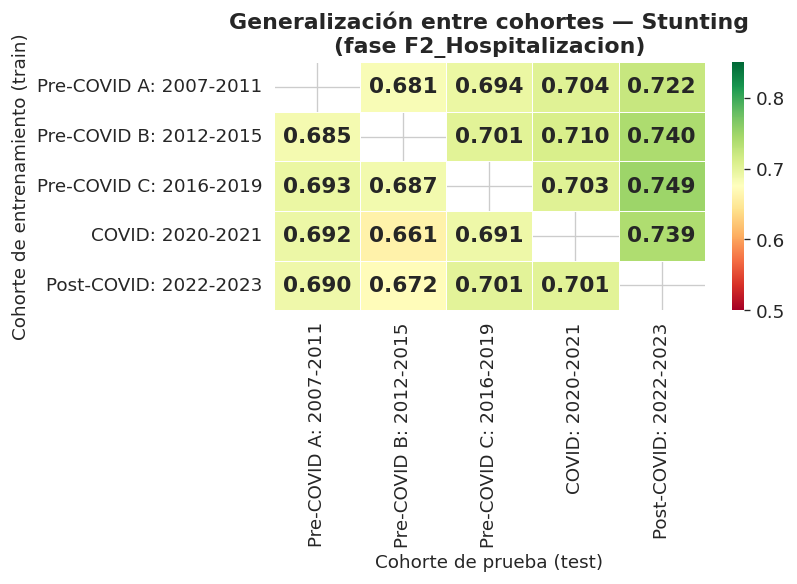

In [23]:
# --- 9.5 Validación cruzada entre cohortes ---
print('=== VALIDACIÓN CRUZADA ENTRE COHORTES ===')
print('Train en un periodo → Test en otro (Stunting, F2_Hospitalizacion)\n')

outcome_cv   = 'Stunting'
target_cv    = OUTCOMES[outcome_cv][0]
fase_cv      = 'F2_Hospitalizacion'
feats_cv_raw = cumulative_features[fase_cv]
cross_auc    = {}

for train_c in COHORTS_ORDER:
    df_tr    = df_main[df_main['cohort'] == train_c]
    feats_ok = [f for f in feats_cv_raw
                if f in df_tr.columns and df_tr[f].notna().mean() > 0.05]
    X_tr, y_tr = get_model_data(df_tr, feats_ok, target_cv)
    if len(y_tr) < 100 or y_tr.sum() < 15:
        continue

    n_pos = y_tr.sum(); n_neg = len(y_tr) - n_pos
    model_cv = lgb.train(
        {'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.05,
         'num_leaves': 63, 'min_child_samples': 30, 'verbose': -1,
         'scale_pos_weight': round(n_neg / n_pos, 2), 'seed': 42},
        lgb.Dataset(X_tr, label=y_tr), num_boost_round=300,
    )
    for test_c in COHORTS_ORDER:
        if test_c == train_c:
            continue
        df_te = df_main[df_main['cohort'] == test_c]
        X_te, y_te = get_model_data(df_te, feats_ok, target_cv)
        if len(y_te) < 50:
            continue
        auc = roc_auc_score(y_te, model_cv.predict(X_te.reindex(columns=feats_ok, fill_value=np.nan)))
        cross_auc[(train_c, test_c)] = auc
        print(f'  Train={train_c}  →  Test={test_c}: AUC={auc:.4f}  (n_test={len(y_te):,})')

cross_mat = pd.DataFrame(index=COHORTS_ORDER, columns=COHORTS_ORDER, dtype=float)
for (tr, te), auc in cross_auc.items():
    cross_mat.loc[tr, te] = auc

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross_mat.astype(float), annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0.50, vmax=0.85,
            mask=cross_mat.isna(), ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'}, linewidths=0.5)
ax.set_xlabel('Cohorte de prueba (test)', fontsize=11)
ax.set_ylabel('Cohorte de entrenamiento (train)', fontsize=11)
ax.set_title(f'Generalización entre cohortes — {outcome_cv}\n(fase {fase_cv})', fontweight='bold')
plt.tight_layout()
plt.show()

Features comunes a los 3 cohortes: 192

Top 15 features con mayor drift entre cohortes:
                     feature  drift_range  Pre-COVID A: 2007-2011  Pre-COVID B: 2012-2015  Pre-COVID C: 2016-2019  COVID: 2020-2021  Post-COVID: 2022-2023
          CSP_IngresoMensual 1594078.8615            1303103.2278            1674018.8840            2074169.3619      2300204.1571           2897182.0893
                PesosalidaPC     276.9006               2489.3149               2574.5529               2615.2096         2738.8855              2766.2155
                    ERN_Peso     268.3099               1935.1492               2054.5081               2125.1775         2186.8164              2203.4591
               HD_PesoSalida     187.4938               2257.6597               2445.1535               2368.6049         2306.3118              2320.4430
                CP_PesoMadre       5.8889                 56.2011                 57.6744                 60.0435           61.4830      

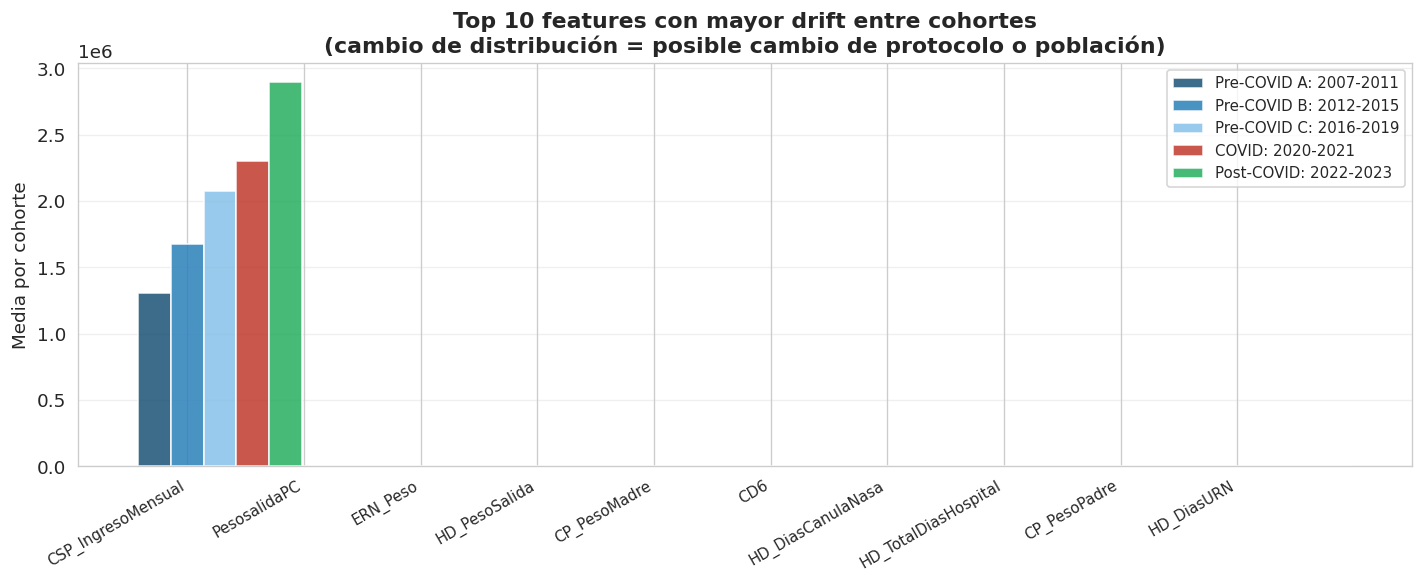

In [24]:
# --- 9.6 Detección de drift de features entre cohortes ---
fase_drift  = 'F6_9meses'
feats_drift = cumulative_features[fase_drift]

feat_avail_d, feat_new_d = align_features_across_cohorts(df_main, feats_drift)
common_feats   = set.intersection(*[feat_avail_d[c] for c in COHORTS_ORDER])
numeric_common = [f for f in common_feats if pd.api.types.is_numeric_dtype(df_main[f])]

drift_rows = []
for feat in numeric_common:
    means = {c: df_main[df_main['cohort']==c][feat].dropna().mean() for c in COHORTS_ORDER}
    vals  = [v for v in means.values() if not np.isnan(v)]
    if len(vals) >= 2:
        drift_rows.append({'feature': feat, 'drift_range': max(vals)-min(vals), **means})

drift_df = pd.DataFrame(drift_rows).sort_values('drift_range', ascending=False).reset_index(drop=True)

print(f'Features comunes a los 3 cohortes: {len(common_feats)}')
print(f'\nTop 15 features con mayor drift entre cohortes:')
cols_show = ['feature', 'drift_range'] + COHORTS_ORDER
print(drift_df[cols_show].head(15).round(4).to_string(index=False))

top10 = drift_df.head(10)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top10)); width = 0.28
for i, cohort_name in enumerate(COHORTS_ORDER):
    ax.bar(x + i*width, top10[cohort_name].values, width=width,
           color=COHORT_COLORS[cohort_name], alpha=0.85, label=cohort_name)
ax.set_xticks(x+width); ax.set_xticklabels(top10['feature'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Media por cohorte')
ax.set_title('Top 10 features con mayor drift entre cohortes\n'
             '(cambio de distribución = posible cambio de protocolo o población)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [25]:
# --- 9.7 Análisis comparativo Pre/Durante/Post-COVID (Stunting, F2) ---

print('=== COMPARACIÓN PRE / DURANTE / POST COVID ===')
print('Stunting, F2_Hospitalizacion — AUC por era\n')

feats_s = [f for f in cumulative_features['F2_Hospitalizacion'] if f in df.columns]

grupos_covid = [
    ('Pre-COVID (A+B+C, 2007-2019)',
     df_main[df_main['cohort'].str.startswith('Pre-COVID')]),
    ('COVID (2020-2021)',
     df_main[df_main['cohort'] == 'COVID: 2020-2021']),
    ('Post-COVID (2022-2023)',
     df_main[df_main['cohort'] == 'Post-COVID: 2022-2023']),
]

for label, df_era in grupos_covid:
    X_s, y_s = get_model_data(df_era, feats_s, 'stunting12m')
    if len(y_s) < 100 or y_s.sum() < 15:
        print(f'  {label}: n insuficiente (n={len(y_s)}, pos={y_s.sum() if len(y_s)>0 else 0})')
        continue
    m, _, _ = train_lgbm_cv(X_s, y_s)
    prev = y_s.mean()
    print(f'  {label}:')
    print(f'    AUC={m["AUC"].mean():.4f} ± {m["AUC"].std():.4f}  '
          f'n={len(y_s):,}  prevalencia={prev:.1%}')

print('\nInterpretación:')
print('  - Si AUC cae durante COVID → disrupción en la calidad/disponibilidad de datos')
print('  - Si prevalencia sube en COVID → impacto real de la pandemia en malnutrición')
print('  - Si AUC se recupera post-COVID → resiliencia del sistema predictivo')


=== COMPARACIÓN PRE / DURANTE / POST COVID ===
Stunting, F2_Hospitalizacion — AUC por era

  Pre-COVID (A+B+C, 2007-2019):
    AUC=0.7327 ± 0.0167  n=18,770  prevalencia=17.0%
  COVID (2020-2021):
    AUC=0.7478 ± 0.0066  n=3,587  prevalencia=13.2%
  Post-COVID (2022-2023):
    AUC=0.7525 ± 0.0117  n=1,984  prevalencia=14.1%

Interpretación:
  - Si AUC cae durante COVID → disrupción en la calidad/disponibilidad de datos
  - Si prevalencia sube en COVID → impacto real de la pandemia en malnutrición
  - Si AUC se recupera post-COVID → resiliencia del sistema predictivo


## 9.8 Dashboard — Impacto COVID en malnutrición y modelo predictivo

Cuatro paneles integrados:
1. **Tendencia de prevalencia por año** — ¿subió la malnutrición durante COVID?
2. **Registros por año** — ¿hubo caída de asistencia en pandemia?
3. **AUC por cohorte y fase clave** — ¿sigue funcionando el modelo?
4. **Heatmap AUC cohortes × fases** — visión completa de la cascada por era


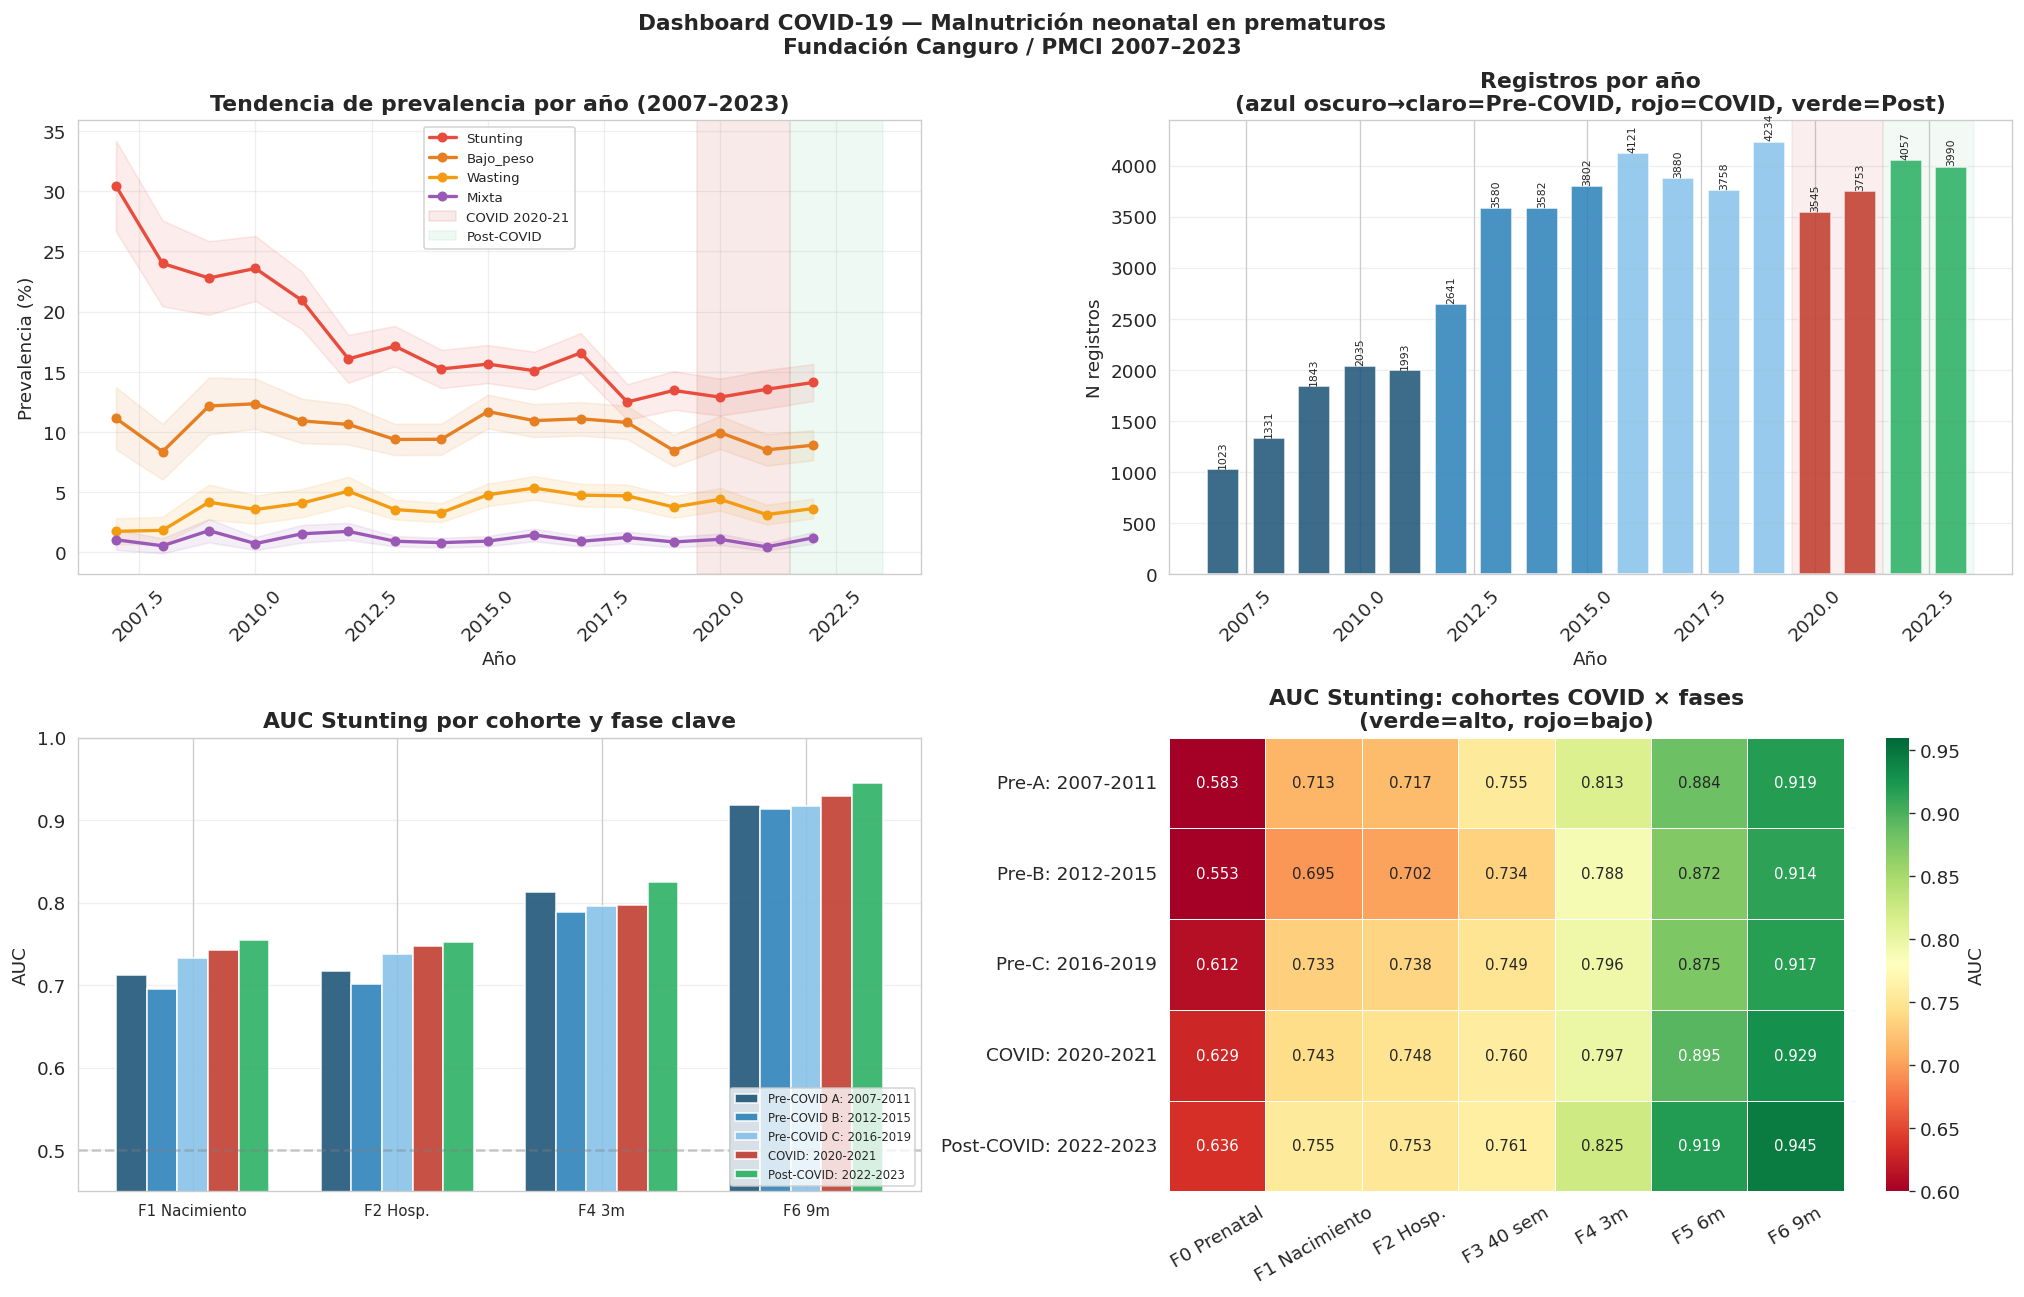

In [26]:
# --- 9.8 Dashboard: prevalencia, asistencia, AUC por era COVID ---

years_raw = sorted([y for y in df_main['_anocat_num'].dropna().unique()])
year_labels = [int(y) + 2002 for y in years_raw]

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# ── Panel 1: Prevalencia por año ─────────────────────────────────────────────
ax1 = axes[0][0]
for outcome_name, (target_col, color, _) in OUTCOMES.items():
    prevs, cis = [], []
    for y in years_raw:
        sub = df_main[df_main['_anocat_num'] == y][target_col].dropna()
        if len(sub) < 20:
            prevs.append(np.nan); cis.append(0)
            continue
        p  = sub.mean()
        ci = 1.96 * np.sqrt(p * (1 - p) / len(sub))
        prevs.append(p * 100); cis.append(ci * 100)
    ax1.plot(year_labels, prevs, marker='o', color=color, linewidth=2,
             label=outcome_name, markersize=5)
    ax1.fill_between(year_labels,
                     np.array(prevs) - np.array(cis),
                     np.array(prevs) + np.array(cis),
                     alpha=0.10, color=color)
ax1.axvspan(2019.5, 2021.5, alpha=0.10, color='#c0392b', label='COVID 2020-21')
ax1.axvspan(2021.5, 2023.5, alpha=0.07, color='#27ae60', label='Post-COVID')
ax1.set_xlabel('Año'); ax1.set_ylabel('Prevalencia (%)')
ax1.set_title('Tendencia de prevalencia por año (2007–2023)', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# ── Panel 2: N registros por año ─────────────────────────────────────────────
ax2 = axes[0][1]
ns = [len(df_main[df_main['_anocat_num'] == y]) for y in years_raw]
bar_colors = [
    '#c0392b' if 18 <= y <= 19 else
    '#27ae60' if y >= 20 else
    '#1a5276' if y <= 9 else
    '#2980b9' if y <= 13 else '#85c1e9'
    for y in years_raw
]
bars = ax2.bar(year_labels, ns, color=bar_colors, alpha=0.85, edgecolor='white', width=0.7)
ax2.axvspan(2019.5, 2021.5, alpha=0.08, color='#c0392b')
ax2.axvspan(2021.5, 2023.5, alpha=0.05, color='#27ae60')
for bar, n in zip(bars, ns):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(n), ha='center', fontsize=6.5, rotation=90)
ax2.set_xlabel('Año'); ax2.set_ylabel('N registros')
ax2.set_title('Registros por año\n(azul oscuro→claro=Pre-COVID, rojo=COVID, verde=Post)', fontweight='bold')
ax2.tick_params(axis='x', rotation=45); ax2.grid(True, alpha=0.3, axis='y')

# ── Panel 3: AUC Stunting por cohorte y fases clave ──────────────────────────
ax3 = axes[1][0]
fases_clave = ['F1_Nacimiento', 'F2_Hospitalizacion', 'F4_3meses', 'F6_9meses']
x = np.arange(len(fases_clave)); width = 0.15
for i, cohort_name in enumerate(COHORTS_ORDER):
    aucs = [
        resultados_cohort[(cohort_name, 'Stunting', f)]['AUC'].mean()
        if (cohort_name, 'Stunting', f) in resultados_cohort else np.nan
        for f in fases_clave
    ]
    ax3.bar(x + i * width, aucs, width=width,
            color=COHORT_COLORS[cohort_name], alpha=0.88, label=cohort_name)
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax3.set_xticks(x + 2 * width)
ax3.set_xticklabels([fase_labels_short[f].replace('\n',' ') for f in fases_clave], fontsize=9)
ax3.set_ylim(0.45, 1.0); ax3.set_ylabel('AUC')
ax3.set_title('AUC Stunting por cohorte y fase clave', fontweight='bold')
ax3.legend(fontsize=7, loc='lower right'); ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4: Heatmap AUC — 5 cohortes × 7 fases (Stunting) ─────────────────
ax4 = axes[1][1]
heatmap_data = []
for cohort_name in COHORTS_ORDER:
    row = []
    for fase in FASE_ORDER:
        key = (cohort_name, 'Stunting', fase)
        auc = resultados_cohort[key]['AUC'].mean() if key in resultados_cohort else np.nan
        row.append(auc)
    heatmap_data.append(row)
hm_df = pd.DataFrame(
    heatmap_data,
    index=[c.replace('Pre-COVID ','Pre-') for c in COHORTS_ORDER],
    columns=[fase_labels_short[f].replace('\n',' ') for f in FASE_ORDER]
)
sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.60, vmax=0.96, ax=ax4, linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'label': 'AUC'})
ax4.set_title('AUC Stunting: cohortes COVID × fases\n(verde=alto, rojo=bajo)', fontweight='bold')
ax4.tick_params(axis='y', rotation=0); ax4.tick_params(axis='x', rotation=30)

plt.suptitle(
    'Dashboard COVID-19 — Malnutrición neonatal en prematuros\nFundación Canguro / PMCI 2007–2023',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [27]:
# --- 9.9 Tabla resumen ejecutivo y cambio porcentual pre/durante/post-COVID ---

print('=' * 80)
print('RESUMEN EJECUTIVO: ERAS COVID — Prevalencia y AUC por cohorte y outcome')
print('=' * 80)

resumen_rows = []
for cohort_name in COHORTS_ORDER:
    sub_df = df_main[df_main['cohort'] == cohort_name]
    row = {'Cohorte': cohort_name, 'N total': len(sub_df)}
    for outcome_name, (target_col, _, _) in OUTCOMES.items():
        sub = sub_df[target_col].dropna()
        n_v = len(sub)
        p   = sub.mean() if n_v > 0 else np.nan
        ci  = 1.96 * np.sqrt(p * (1-p) / n_v) if n_v > 0 else np.nan
        row[f'{outcome_name} N']     = n_v
        row[f'{outcome_name} Prev']  = f'{p:.1%} ±{ci:.1%}' if not np.isnan(p) else '—'
        for fase_k in ['F1_Nacimiento', 'F6_9meses']:
            key = (cohort_name, outcome_name, fase_k)
            auc = resultados_cohort[key]['AUC'].mean() if key in resultados_cohort else np.nan
            row[f'{outcome_name} AUC {fase_k[:2]}'] = f'{auc:.3f}' if not np.isnan(auc) else '—'
    resumen_rows.append(row)

resumen_df = pd.DataFrame(resumen_rows).set_index('Cohorte')

# Imprimir por outcome para legibilidad
for outcome_name in OUTCOMES:
    cols = ['N total',
            f'{outcome_name} N', f'{outcome_name} Prev',
            f'{outcome_name} AUC F1', f'{outcome_name} AUC F6']
    cols = [c for c in cols if c in resumen_df.columns]
    print(f'\n── {outcome_name} ──')
    print(resumen_df[cols].to_string())

# ── Cambio en prevalencia Stunting respecto a Pre-COVID A ────────────────────
print('\n' + '=' * 60)
print('Cambio en prevalencia Stunting vs Pre-COVID A (referencia)')
print('=' * 60)
prev_ref = None
for cohort_name in COHORTS_ORDER:
    sub = df_main[df_main['cohort'] == cohort_name]['stunting12m'].dropna()
    if len(sub) == 0:
        continue
    p = sub.mean()
    if prev_ref is None:
        prev_ref = p
        print(f'  {cohort_name}: {p:.1%}  (referencia base)')
    else:
        delta_pp  = (p - prev_ref) * 100          # diferencia en puntos porcentuales
        delta_rel = (p - prev_ref) / prev_ref * 100  # cambio relativo
        signo = '+' if delta_pp >= 0 else ''
        print(f'  {cohort_name}: {p:.1%}  ({signo}{delta_pp:.1f} pp, {signo}{delta_rel:.1f}%)')

print('\nNota: pp = puntos porcentuales respecto a Pre-COVID A (2007-2011)')


RESUMEN EJECUTIVO: ERAS COVID — Prevalencia y AUC por cohorte y outcome

── Stunting ──
                        N total  Stunting N Stunting Prev Stunting AUC F1 Stunting AUC F6
Cohorte                                                                                  
Pre-COVID A: 2007-2011     8225        3899   23.7% ±1.3%           0.713           0.919
Pre-COVID B: 2012-2015    13605        7253   16.0% ±0.8%           0.695           0.914
Pre-COVID C: 2016-2019    15993        7618   14.4% ±0.8%           0.733           0.917
COVID: 2020-2021           7298        3587   13.2% ±1.1%           0.743           0.929
Post-COVID: 2022-2023      8047        1984   14.1% ±1.5%           0.755           0.945

── Bajo_peso ──
                        N total  Bajo_peso N Bajo_peso Prev Bajo_peso AUC F1 Bajo_peso AUC F6
Cohorte                                                                                      
Pre-COVID A: 2007-2011     8225         3920    11.2% ±1.0%            0.720 

## 9.10 Importancia de Features por (Cohorte × Outcome × Fase)

Para cada combinación se entrena un LightGBM independiente y se computa **SHAP** para
extraer los factores más relevantes. Resulta en hasta **4 outcomes × 5 cohortes × 7 fases = 140**
análisis de importancia.

Salidas:
- `shap_importance_cohort[(cohort, outcome, fase)]` — DataFrame con `mean_abs` y `mean_signed`.
- Heatmaps comparativos por cohorte (magnitud y dirección protector/riesgo).
- CSV `dashboard_data/importancia_features_por_cohorte.csv`.
- Análisis de **drift de importancia** entre Pre-COVID y COVID.


In [28]:
# --- 9.10 Importancia SHAP por (cohorte x outcome x fase) ---
import shap

SHAP_PARAMS = {
    'objective': 'binary', 'metric': 'auc',
    'learning_rate': 0.05, 'num_leaves': 63, 'max_depth': -1,
    'min_child_samples': 30, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5,
    'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'verbose': -1, 'seed': 42,
}

shap_importance_cohort = {}  # (cohort, outcome, fase) -> DataFrame
total = len(COHORTS_ORDER) * len(OUTCOMES) * len(FASE_ORDER)
done  = 0

for cohort_name in COHORTS_ORDER:
    df_c = df_main[df_main['cohort'] == cohort_name].copy()
    for outcome_name, (target_col, _, _) in OUTCOMES.items():
        for fase in FASE_ORDER:
            done += 1
            feats_c = [f for f in cumulative_features[fase]
                       if f in df_c.columns and df_c[f].notna().mean() > 0.05]
            X, y = get_model_data(df_c, feats_c, target_col)
            if len(y) < 100 or y.sum() < 15:
                continue

            n_pos, n_neg = y.sum(), len(y) - y.sum()
            params = {**SHAP_PARAMS, 'scale_pos_weight': round(n_neg / n_pos, 2)}

            model = lgb.train(params, lgb.Dataset(X, label=y), num_boost_round=300)

            explainer = shap.TreeExplainer(model)
            sv = explainer.shap_values(X)
            if isinstance(sv, list):           # version antigua: list[neg, pos]
                sv = sv[1]

            shap_importance_cohort[(cohort_name, outcome_name, fase)] = (
                pd.DataFrame({
                    'feature':     X.columns,
                    'mean_abs':    np.abs(sv).mean(axis=0),
                    'mean_signed': sv.mean(axis=0),
                    'n_train':     len(y),
                    'prevalencia': y.mean(),
                }).sort_values('mean_abs', ascending=False).reset_index(drop=True)
            )

            if done % 10 == 0:
                print(f'  [{done}/{total}] OK - {cohort_name} | {outcome_name} | {fase}')

print(f'\nCombinaciones procesadas: {len(shap_importance_cohort)}/{total}')


  [10/140] OK - Pre-COVID A: 2007-2011 | Bajo_peso | F2_Hospitalizacion
  [20/140] OK - Pre-COVID A: 2007-2011 | Wasting | F5_6meses
  [30/140] OK - Pre-COVID B: 2012-2015 | Stunting | F1_Nacimiento
  [40/140] OK - Pre-COVID B: 2012-2015 | Bajo_peso | F4_3meses
  [50/140] OK - Pre-COVID B: 2012-2015 | Mixta | F0_Prenatal_Parto
  [60/140] OK - Pre-COVID C: 2016-2019 | Stunting | F3_40semanas
  [70/140] OK - Pre-COVID C: 2016-2019 | Bajo_peso | F6_9meses
  [80/140] OK - Pre-COVID C: 2016-2019 | Mixta | F2_Hospitalizacion
  [90/140] OK - COVID: 2020-2021 | Stunting | F5_6meses
  [100/140] OK - COVID: 2020-2021 | Wasting | F1_Nacimiento
  [110/140] OK - COVID: 2020-2021 | Mixta | F4_3meses
  [120/140] OK - Post-COVID: 2022-2023 | Bajo_peso | F0_Prenatal_Parto
  [130/140] OK - Post-COVID: 2022-2023 | Wasting | F3_40semanas
  [140/140] OK - Post-COVID: 2022-2023 | Mixta | F6_9meses

Combinaciones procesadas: 140/140


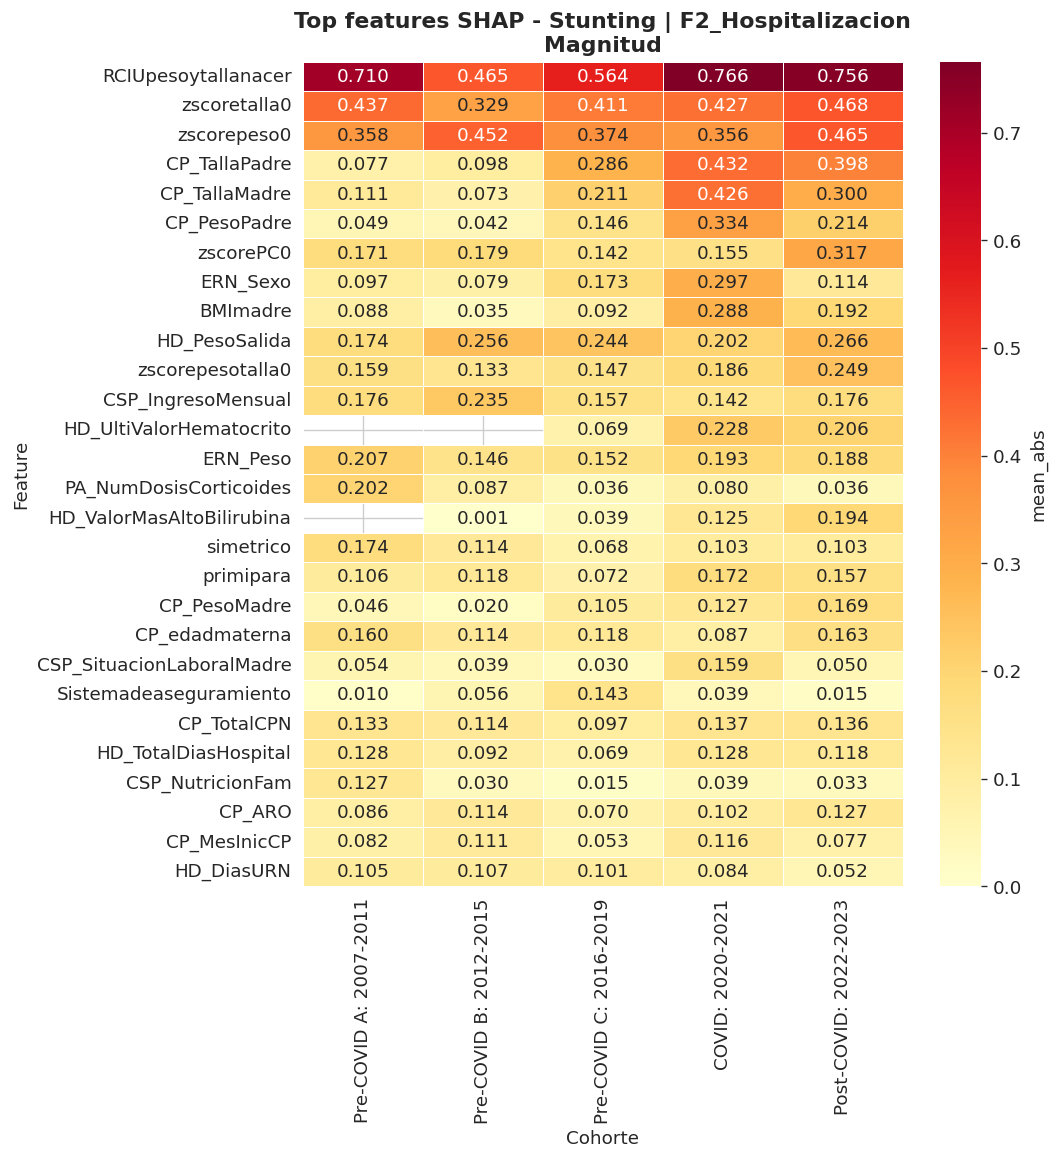

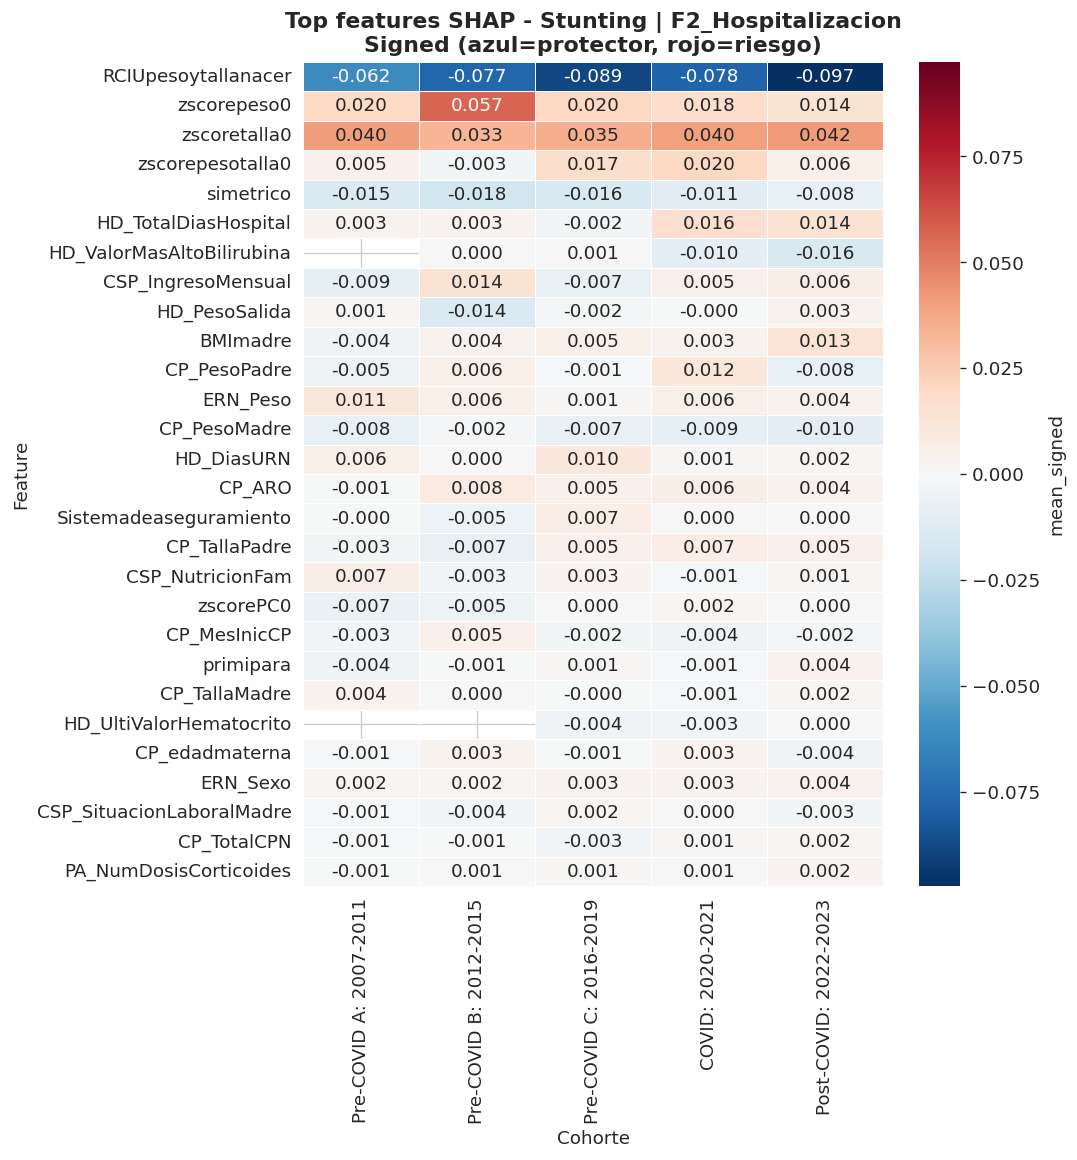

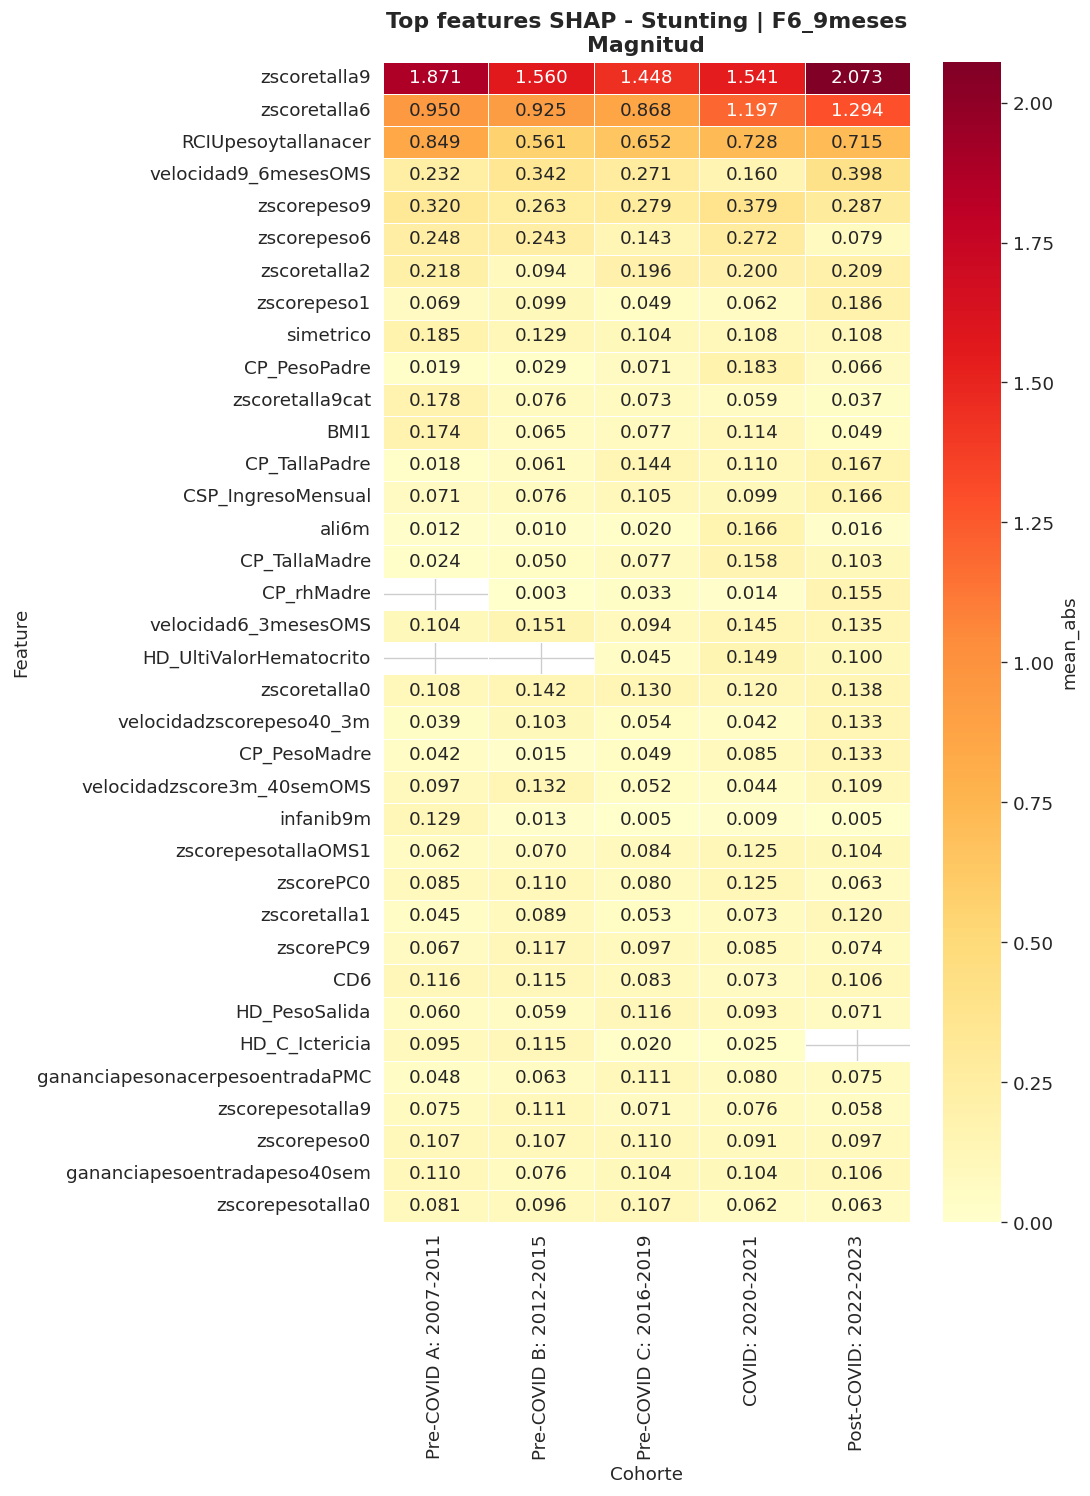

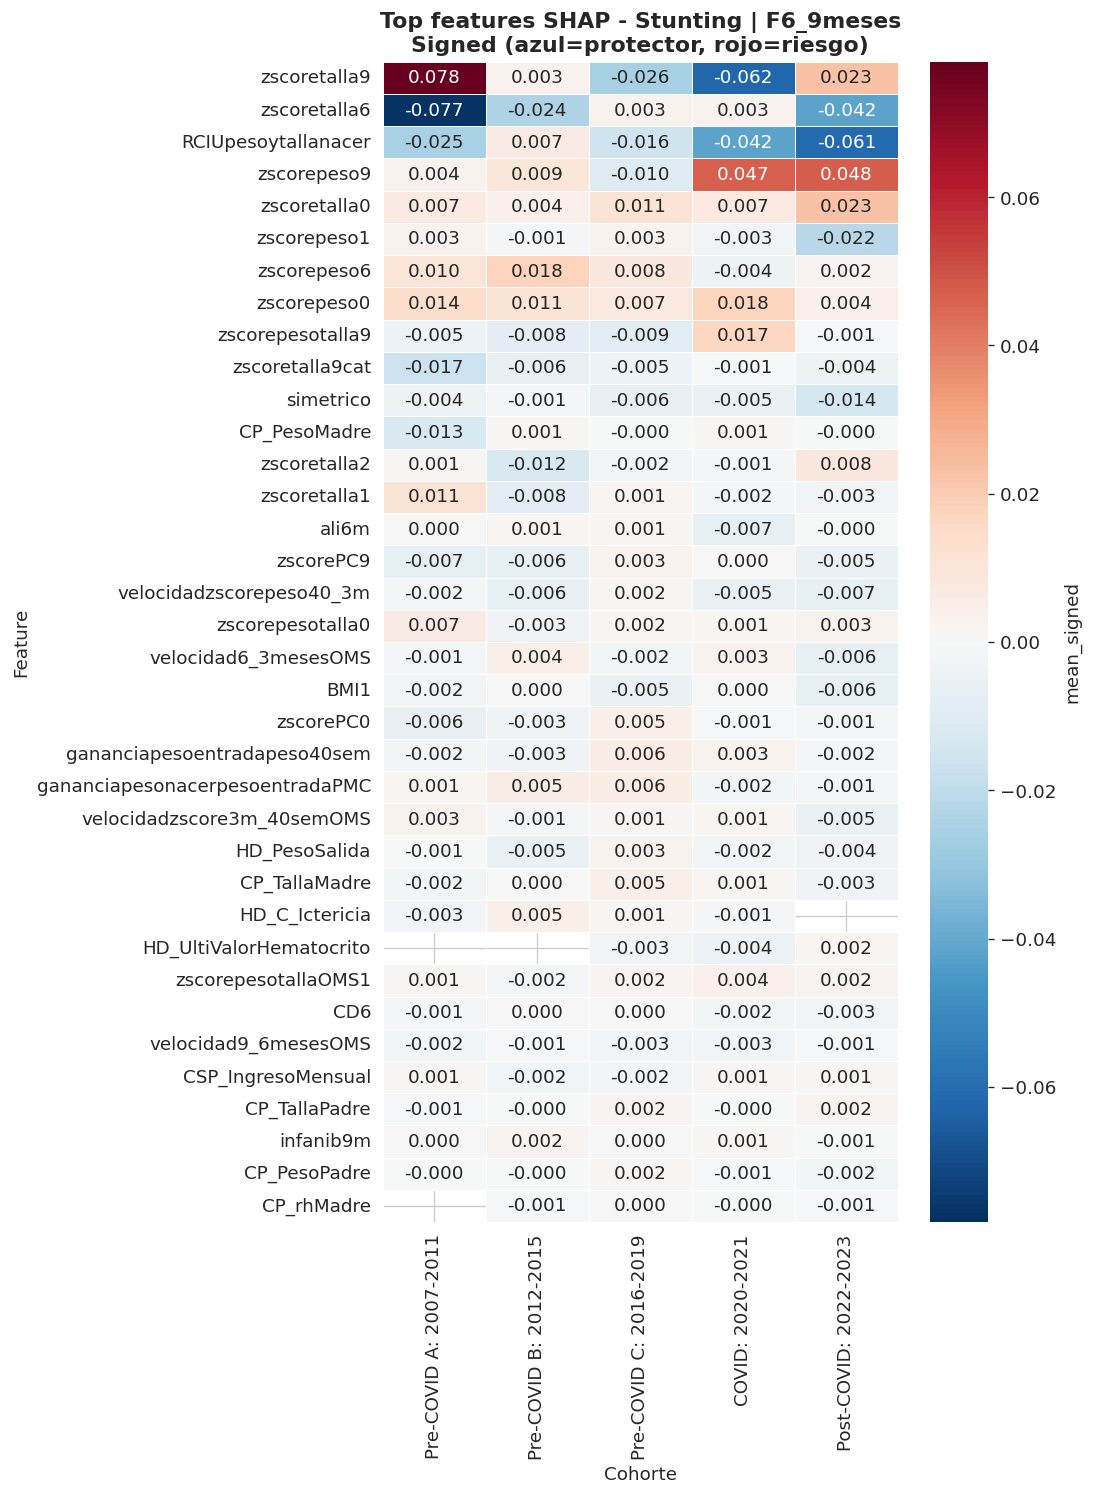

In [29]:
# --- 9.11 Heatmap top features x cohortes ---
def heatmap_top_features(outcome_name, fase, top_n=15, signed=False):
    """Heatmap de top-N features por cohorte para un (outcome, fase) fijo."""
    metric = 'mean_signed' if signed else 'mean_abs'
    cmap   = 'RdBu_r'      if signed else 'YlOrRd'

    top_feats = set()
    for c in COHORTS_ORDER:
        d = shap_importance_cohort.get((c, outcome_name, fase))
        if d is not None:
            top_feats.update(d.head(top_n)['feature'])

    mat = pd.DataFrame(index=sorted(top_feats), columns=COHORTS_ORDER, dtype=float)
    for c in COHORTS_ORDER:
        d = shap_importance_cohort.get((c, outcome_name, fase))
        if d is not None:
            mat[c] = mat.index.map(d.set_index('feature')[metric]).astype(float)

    mat = mat.loc[mat.abs().max(axis=1).sort_values(ascending=False).index]
    if len(mat) == 0:
        print(f'Sin datos para {outcome_name} en {fase}'); return None

    vmax = mat.abs().max().max()
    vmin = -vmax if signed else 0
    fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(mat))))
    sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap=cmap,
                vmin=vmin, vmax=vmax, linewidths=0.4,
                cbar_kws={'label': metric}, ax=ax)
    titulo_metric = 'Signed (azul=protector, rojo=riesgo)' if signed else 'Magnitud'
    ax.set_title(f'Top features SHAP - {outcome_name} | {fase}\n{titulo_metric}',
                 fontweight='bold')
    ax.set_xlabel('Cohorte'); ax.set_ylabel('Feature')
    plt.tight_layout(); plt.show()
    return mat

# Ejemplos clave: Stunting en F2 (hospitalizacion) y F6 (9 meses)
for fase_x in ['F2_Hospitalizacion', 'F6_9meses']:
    heatmap_top_features('Stunting', fase_x, top_n=15)
    heatmap_top_features('Stunting', fase_x, top_n=15, signed=True)


In [39]:
# --- 9.12 Export CSV + analisis de drift entre eras ---
import os
os.makedirs('dashboard_data', exist_ok=True)

# 1) CSV exhaustivo (top-15 por combinacion)
rows = []
for (cohort, outcome, fase), d in shap_importance_cohort.items():
    top = d.head(15).copy()
    top.insert(0, 'fase',    fase)
    top.insert(0, 'outcome', outcome)
    top.insert(0, 'cohort',  cohort)
    top['rank'] = range(1, len(top) + 1)
    rows.append(top)

importancia_full = pd.concat(rows, ignore_index=True)
out = 'dashboard_data/importancia_features_por_cohorte.csv'
importancia_full.to_csv(out, index=False)
print(f'Guardado: {out}  ({len(importancia_full):,} filas)\n')

# 2) Drift entre Pre-COVID C y COVID: que features entran/salen del top-10
def drift_top(outcome_name, fase, c_pre, c_post, k=10):
    pre  = shap_importance_cohort.get((c_pre,  outcome_name, fase))
    post = shap_importance_cohort.get((c_post, outcome_name, fase))
    if pre is None or post is None: return None
    s_pre, s_post = set(pre.head(k)['feature']), set(post.head(k)['feature'])
    return {
        'salieron': sorted(s_pre - s_post),
        'entraron': sorted(s_post - s_pre),
        'estables': sorted(s_pre & s_post),
    }

for outcome_x in OUTCOMES:
    print(f'\n=== {outcome_x} | F6_9meses - Drift top-10: Pre-COVID C -> COVID ===')
    d = drift_top(outcome_x, 'F6_9meses',
                  'Pre-COVID C: 2016-2019', 'COVID: 2020-2021')
    if d is None:
        print('  (sin datos suficientes en alguna de las dos eras)')
        continue
    print(f'  Salieron : {d["salieron"]}')
    print(f'  Entraron : {d["entraron"]}')
    print(f'  Estables : {d["estables"]}')


Guardado: dashboard_data/importancia_features_por_cohorte.csv  (2,100 filas)


=== Stunting | F6_9meses - Drift top-10: Pre-COVID C -> COVID ===
  Salieron : ['CP_TallaPadre', 'HD_PesoSalida', 'zscoretalla0']
  Entraron : ['CP_PesoPadre', 'CP_TallaMadre', 'ali6m']
  Estables : ['RCIUpesoytallanacer', 'velocidad9_6mesesOMS', 'zscorepeso6', 'zscorepeso9', 'zscoretalla2', 'zscoretalla6', 'zscoretalla9']

=== Bajo_peso | F6_9meses - Drift top-10: Pre-COVID C -> COVID ===
  Salieron : ['CD6', 'ERN_Sexo']
  Entraron : ['BMImadre', 'zscorePC9']
  Estables : ['CP_PesoPadre', 'velocidad6_3mesesOMS', 'velocidad9_6mesesOMS', 'zscorepeso6', 'zscorepeso9', 'zscorepesotalla9', 'zscoretalla6', 'zscoretalla9']

=== Wasting | F6_9meses - Drift top-10: Pre-COVID C -> COVID ===
  Salieron : ['HD_PesoSalida', 'HD_UltiValorHematocrito', 'gananciatallanacertallaentradaPMC', 'velocidad6_3mesesOMS', 'zscorePC6', 'zscoretalla0']
  Entraron : ['gananciapesonacerpesoentradaPMC', 'velocidad9_6mesesOMS', 'velocida

In [50]:
import os
import json as _json
from datetime import datetime
os.makedirs('dashboard_data', exist_ok=True)

  # 1) Features de entrada por fase
features_por_fase_json = {
  fase: {'n_features': len(feats), 'features': list(feats)}
  for fase, feats in cumulative_features.items()
}
with open('dashboard_data/features_por_fase.json', 'w', encoding='utf-8') as f_out:
  _json.dump({
      'generado':          datetime.now().strftime('%Y-%m-%d %H:%M'),
      'descripcion':       'Features acumulativas de entrada al LightGBM por fase',
      'fase_order':        FASE_ORDER,
      'features_por_fase': features_por_fase_json,
  }, f_out, ensure_ascii=False, indent=2)
print('Guardado: dashboard_data/features_por_fase.json')

# 2) Importancia SHAP anidada (cohort -> outcome -> fase)
importancia_json = {}
for (cohort, outcome, fase), d in shap_importance_cohort.items():
  importancia_json.setdefault(cohort, {}).setdefault(outcome, {})[fase] = {
      'n_train':     int(d['n_train'].iloc[0]),
      'prevalencia': round(float(d['prevalencia'].iloc[0]), 4),
      'top_features': [
          {
              'rank':        i + 1,
              'feature':     str(r['feature']),
              'mean_abs':    round(float(r['mean_abs']),    6),
              'mean_signed': round(float(r['mean_signed']), 6),
          }
          for i, r in d.head(20).iterrows()
      ],
  }
with open('dashboard_data/importancia_features_por_cohorte.json', 'w', encoding='utf-8') as f_out:
  _json.dump({
      'generado':    datetime.now().strftime('%Y-%m-%d %H:%M'),
      'descripcion': 'Top-20 features SHAP por (cohorte x outcome x fase). mean_signed>0=riesgo, <0=protector.',
      'cohorts':     COHORTS_ORDER,
      'outcomes':    list(OUTCOMES.keys()),
      'fases':       FASE_ORDER,
      'importancia': importancia_json,
  }, f_out, ensure_ascii=False, indent=2)
print('Guardado: dashboard_data/importancia_features_por_cohorte.json')

# 3) Drift Pre-COVID C -> COVID
def _drift_top(outcome_name, fase, c_pre, c_post, k=10):
  pre  = shap_importance_cohort.get((c_pre,  outcome_name, fase))
  post = shap_importance_cohort.get((c_post, outcome_name, fase))
  if pre is None or post is None: return None
  s_pre, s_post = set(pre.head(k)['feature']), set(post.head(k)['feature'])
  return {
      'salieron': sorted(s_pre - s_post),
      'entraron': sorted(s_post - s_pre),
      'estables': sorted(s_pre & s_post),
  }

drift_summary = {}
for outcome_x in OUTCOMES:
  for fase_x in FASE_ORDER:
      d = _drift_top(outcome_x, fase_x,
                     'Pre-COVID C: 2016-2019', 'COVID: 2020-2021')
      if d is not None:
          drift_summary.setdefault(outcome_x, {})[fase_x] = d

with open('dashboard_data/drift_importancia_pre_covid.json', 'w', encoding='utf-8') as f_out:
  _json.dump({
      'generado':    datetime.now().strftime('%Y-%m-%d %H:%M'),
      'descripcion': 'Drift top-10: Pre-COVID C (2016-2019) -> COVID (2020-2021)',
      'k_top':       10,
      'drift':       drift_summary,
  }, f_out, ensure_ascii=False, indent=2)
print('Guardado: dashboard_data/drift_importancia_pre_covid.json')

print('\n✓ 3 archivos JSON exportados a dashboard_data/')

Guardado: dashboard_data/features_por_fase.json
Guardado: dashboard_data/importancia_features_por_cohorte.json
Guardado: dashboard_data/drift_importancia_pre_covid.json

✓ 3 archivos JSON exportados a dashboard_data/


## 10. Clustering de Trayectorias de Riesgo

**Objetivo**: identificar perfiles de paciente según cómo evoluciona su probabilidad de Stunting
a lo largo de las 7 fases de la cascada.

**Metodología**:
- **Opción A**: K-means sobre la matriz de probabilidades OOF (paciente × 7 fases).
  Cada paciente queda representado por su trayectoria de riesgo.
- **Opción B**: SHAP por cluster — ¿qué features explican cada perfil?

**Perfiles esperados** (ejemplos típicos):
- Riesgo siempre alto
- Riesgo siempre bajo
- Riesgo tardío (aumenta en fases finales)
- Riesgo que mejora con el seguimiento


In [51]:
# --- 10.1 Construcción de la matriz OOF y selección de k ---

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

outcome_clust = 'Stunting'
target_clust  = OUTCOMES[outcome_clust][0]

# Fases con predicciones OOF disponibles
phases_ok = [f for f in FASE_ORDER if (outcome_clust, f) in oof_preds]

# Matriz: filas=pacientes, columnas=fases (prob. OOF de Stunting)
oof_matrix = np.column_stack(
    [oof_preds[(outcome_clust, f)][0] for f in phases_ok]
)  # shape: (n_patients, n_phases)
y_true_vec = oof_preds[(outcome_clust, phases_ok[-1])][1]

print(f'Matriz OOF: {oof_matrix.shape}  '
      f'(pacientes × fases={len(phases_ok)})')
print(f'Prevalencia global Stunting: {y_true_vec.mean():.1%}\n')

# Selección de k por coeficiente de silueta (k = 3..5)
sil_scores = {}
for k in range(3, 6):
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(oof_matrix)
    sil = silhouette_score(oof_matrix, lbl,
                           sample_size=min(8000, len(lbl)), random_state=42)
    sil_scores[k] = sil
    print(f'  k={k}: silhouette={sil:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nK seleccionado: {best_k}')

km_final      = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(oof_matrix)

# Reordenar clusters por prevalencia descendente (cluster 1 = mayor riesgo)
prev_order = np.argsort(
    [-y_true_vec[cluster_labels == k].mean() for k in range(best_k)]
)
remap = {old: new for new, old in enumerate(prev_order)}
cluster_labels = np.array([remap[c] for c in cluster_labels])

print('\nDistribución por cluster (ordenado por prevalencia):')
for k in range(best_k):
    mask = cluster_labels == k
    prev = y_true_vec[mask].mean()
    print(f'  Cluster {k+1}: n={mask.sum():,}  prevalencia Stunting={prev:.1%}')


Matriz OOF: (30953, 7)  (pacientes × fases=7)
Prevalencia global Stunting: 17.2%

  k=3: silhouette=0.3982
  k=4: silhouette=0.3797
  k=5: silhouette=0.3331

K seleccionado: 3

Distribución por cluster (ordenado por prevalencia):
  Cluster 1: n=7,620  prevalencia Stunting=56.9%
  Cluster 2: n=9,879  prevalencia Stunting=6.1%
  Cluster 3: n=13,454  prevalencia Stunting=3.0%


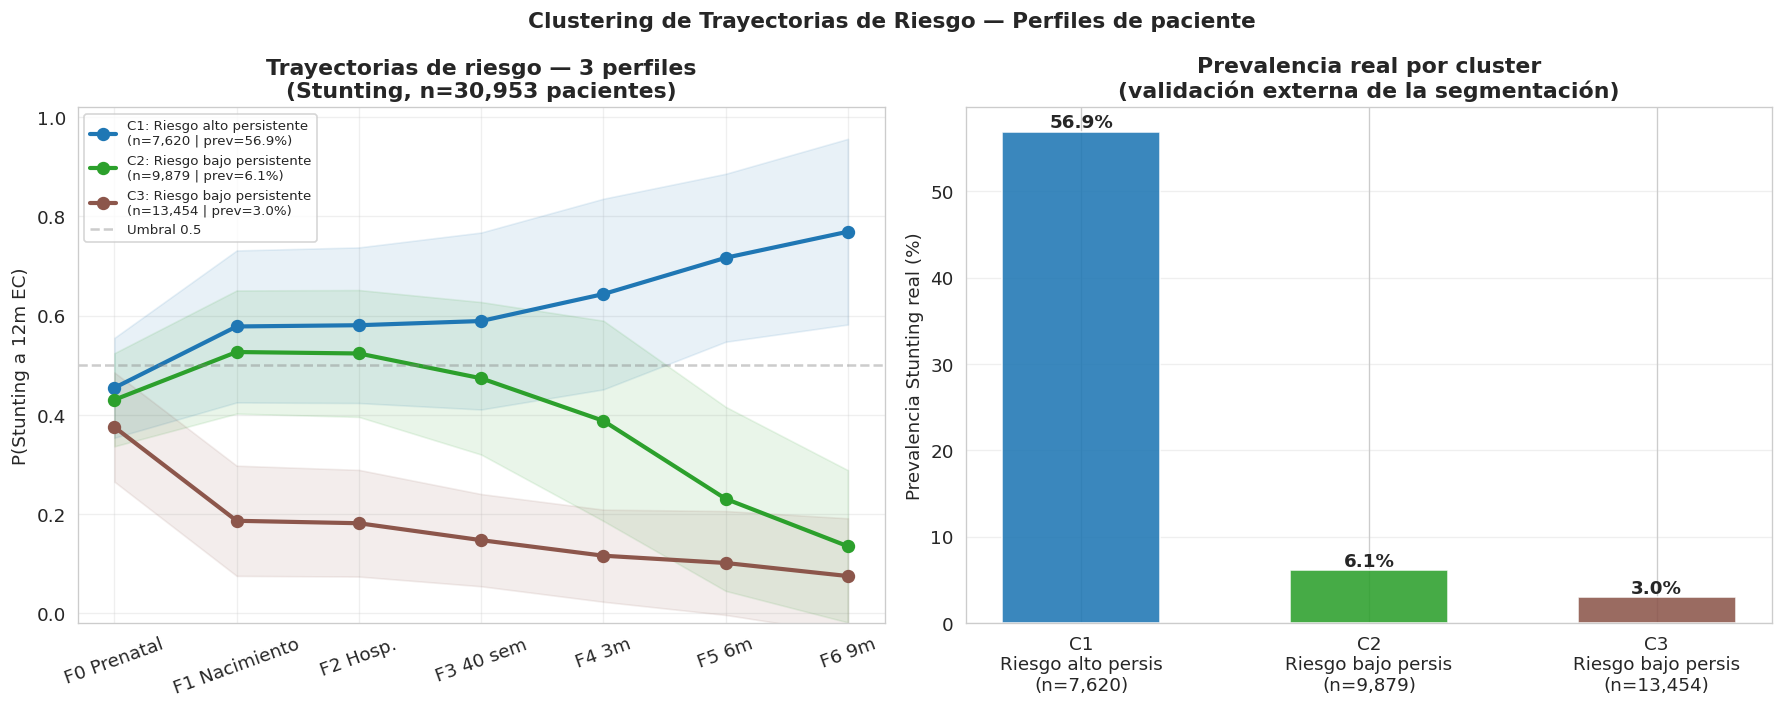

In [52]:
# --- 10.2 Visualización de trayectorias de riesgo por cluster ---

CLUSTER_PALETTE = plt.cm.tab10(np.linspace(0, 0.55, best_k))
fase_short_lbls = [fase_labels_short[f].replace('\n', ' ') for f in phases_ok]

# Etiquetas descriptivas automáticas por forma de trayectoria
def _label_cluster(mean_traj):
    inicio, fin = mean_traj[0], mean_traj[-1]
    maximo      = mean_traj.max()
    if fin > 0.55:   return 'Riesgo alto persistente'
    if fin < 0.15:   return 'Riesgo bajo persistente'
    if fin > inicio * 1.5: return 'Riesgo tardío (creciente)'
    if fin < inicio * 0.6: return 'Riesgo que se resuelve'
    return 'Riesgo moderado estable'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izq: trayectorias medias por cluster
ax1 = axes[0]
cluster_labels_text = []
for k in range(best_k):
    mask      = cluster_labels == k
    mean_traj = oof_matrix[mask].mean(axis=0)
    std_traj  = oof_matrix[mask].std(axis=0)
    n_k       = mask.sum()
    prev_k    = y_true_vec[mask].mean()
    etiqueta  = _label_cluster(mean_traj)
    cluster_labels_text.append(etiqueta)
    lbl = f'C{k+1}: {etiqueta}\n(n={n_k:,} | prev={prev_k:.1%})'
    ax1.plot(fase_short_lbls, mean_traj, marker='o', linewidth=2.5,
             color=CLUSTER_PALETTE[k], label=lbl, markersize=7)
    ax1.fill_between(range(len(phases_ok)),
                     mean_traj - std_traj, mean_traj + std_traj,
                     alpha=0.10, color=CLUSTER_PALETTE[k])

ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Umbral 0.5')
ax1.set_ylim(-0.02, 1.02)
ax1.set_ylabel('P(Stunting a 12m EC)')
ax1.set_title(f'Trayectorias de riesgo — {best_k} perfiles\n'
              f'(Stunting, n={len(cluster_labels):,} pacientes)',
              fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=20)

# Panel der: prevalencia real por cluster (validación)
ax2 = axes[1]
cluster_prevs = [y_true_vec[cluster_labels == k].mean() for k in range(best_k)]
cluster_ns    = [(cluster_labels == k).sum() for k in range(best_k)]
bar_lbls = [f'C{k+1}\n{cluster_labels_text[k][:18]}\n(n={n:,})'
            for k, n in enumerate(cluster_ns)]
bars = ax2.bar(bar_lbls, [p * 100 for p in cluster_prevs],
               color=CLUSTER_PALETTE, alpha=0.88, edgecolor='white', width=0.55)
for bar, p in zip(bars, cluster_prevs):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, f'{p:.1%}',
             ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Prevalencia Stunting real (%)')
ax2.set_title('Prevalencia real por cluster\n'
              '(validación externa de la segmentación)', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Clustering de Trayectorias de Riesgo — Perfiles de paciente',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


  Cluster 1: SHAP calculado (n_sample=2000)
  Cluster 2: SHAP calculado (n_sample=2000)
  Cluster 3: SHAP calculado (n_sample=2000)


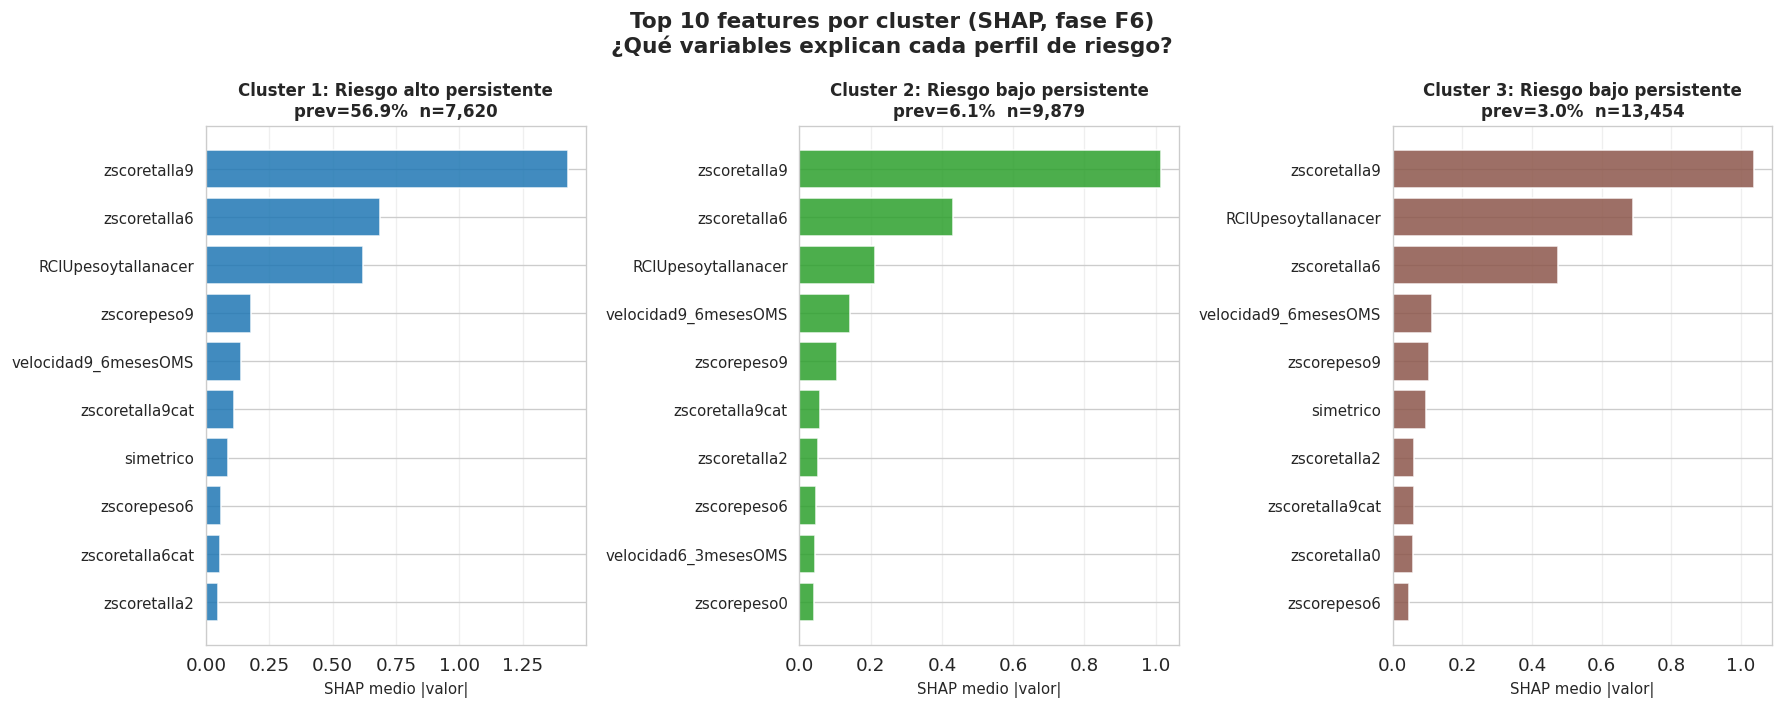

In [53]:
# --- 10.3 SHAP por cluster — ¿qué features definen cada perfil? (F6) ---

feats_f6   = [f for f in cumulative_features['F6_9meses'] if f in df.columns]
df_clust_X, _ = get_model_data(df, feats_f6, target_clust)

# Modelo representativo para SHAP (primer fold de F6)
model_shap = best_models[(outcome_clust, 'F6_9meses')][0]
explainer  = shap.TreeExplainer(model_shap)

# Calcular SHAP medio por cluster (muestra de hasta 2000 pacientes por cluster)
shap_by_cluster = {}
for k in range(best_k):
    mask     = cluster_labels == k
    X_k      = df_clust_X[mask].reset_index(drop=True)
    n_sample = min(2000, len(X_k))
    X_sample = X_k.sample(n_sample, random_state=42)
    sv       = explainer.shap_values(X_sample)
    if isinstance(sv, list):
        sv = sv[1]
    shap_by_cluster[k] = pd.Series(
        np.abs(sv).mean(axis=0), index=feats_f6, name=f'C{k+1}'
    )
    print(f'  Cluster {k+1}: SHAP calculado (n_sample={n_sample})')

# Top 10 features por cluster — subplots individuales
fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 6), sharey=False)
if best_k == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    s    = shap_by_cluster[k].nlargest(10)
    prev = y_true_vec[cluster_labels == k].mean()
    ax.barh(range(len(s)), s.values[::-1],
            color=CLUSTER_PALETTE[k], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index[::-1], fontsize=9)
    ax.set_xlabel('SHAP medio |valor|', fontsize=9)
    ax.set_title(f'Cluster {k+1}: {cluster_labels_text[k]}\n'
                 f'prev={prev:.1%}  n={(cluster_labels==k).sum():,}',
                 fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Top 10 features por cluster (SHAP, fase F6)\n'
             '¿Qué variables explican cada perfil de riesgo?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


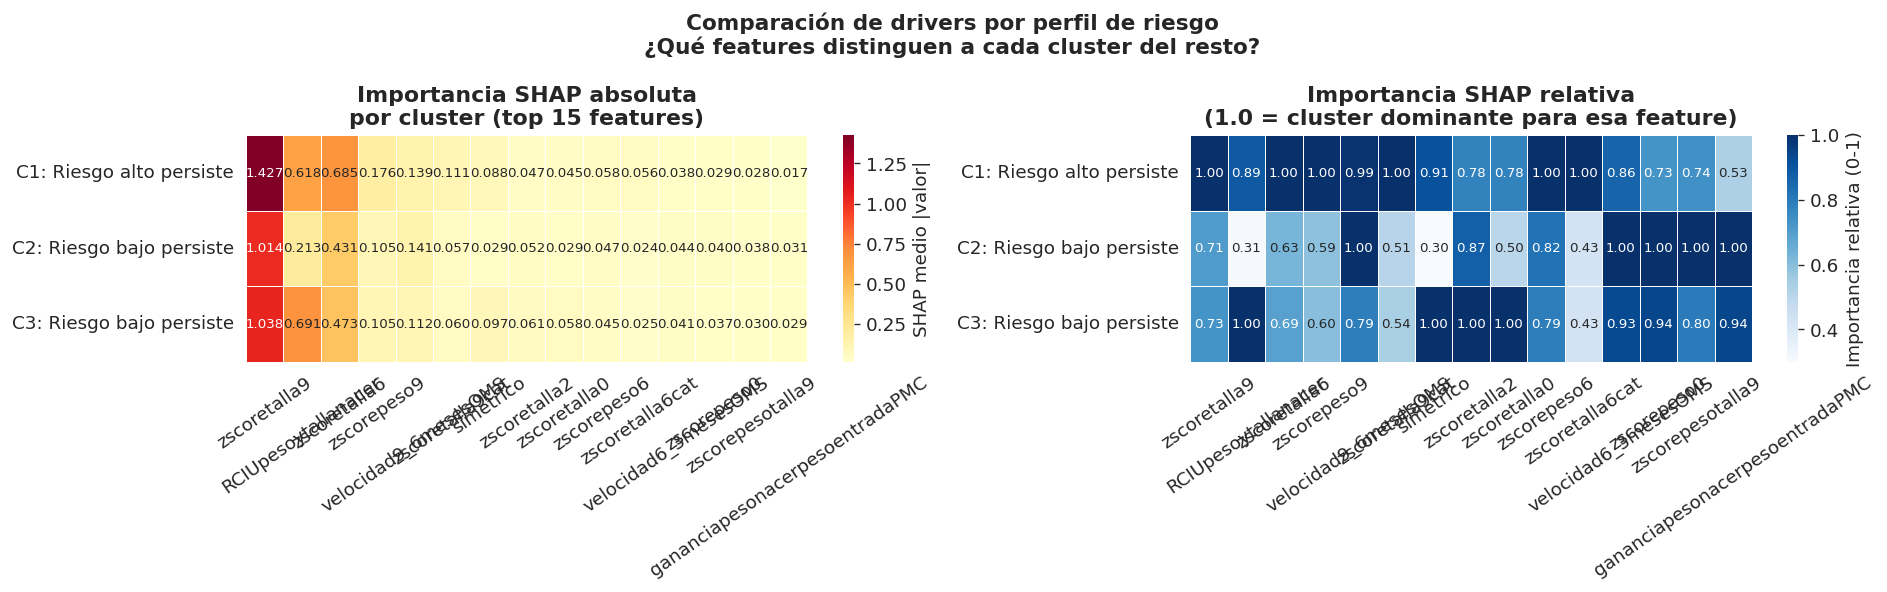


=== FEATURES DOMINANTES POR CLUSTER ===
(feature donde ese cluster tiene la mayor importancia SHAP)

  Cluster 1 (Riesgo alto persistente):
    · zscoretalla9  (SHAP=1.4266)
    · zscoretalla6  (SHAP=0.6848)
    · zscorepeso9  (SHAP=0.1759)
    · zscoretalla9cat  (SHAP=0.1113)
    · zscorepeso6  (SHAP=0.0576)
    · zscoretalla6cat  (SHAP=0.0563)

  Cluster 2 (Riesgo bajo persistente):
    · velocidad9_6mesesOMS  (SHAP=0.1408)
    · velocidad6_3mesesOMS  (SHAP=0.0440)
    · zscorepeso0  (SHAP=0.0397)
    · zscorepesotalla9  (SHAP=0.0378)
    · gananciapesonacerpesoentradaPMC  (SHAP=0.0310)

  Cluster 3 (Riesgo bajo persistente):
    · RCIUpesoytallanacer  (SHAP=0.6909)
    · simetrico  (SHAP=0.0965)
    · zscoretalla2  (SHAP=0.0607)
    · zscoretalla0  (SHAP=0.0579)



In [54]:
# --- 10.4 Heatmap comparativo: importancia SHAP top features × clusters ---

shap_df  = pd.DataFrame(shap_by_cluster).T  # shape: (best_k, n_features)
top_feats = shap_df.max(axis=0).nlargest(15).index
shap_top  = shap_df[top_feats]

# Normalizar por columna (0-1 relativo al cluster con mayor importancia)
shap_norm = shap_top.div(shap_top.max(axis=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izq: importancia absoluta
sns.heatmap(
    shap_top.round(4), annot=True, fmt='.3f',
    cmap='YlOrRd', ax=axes[0], linewidths=0.5,
    annot_kws={'size': 8}, cbar_kws={'label': 'SHAP medio |valor|'}
)
axes[0].set_title('Importancia SHAP absoluta\npor cluster (top 15 features)',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_yticklabels(
    [f'C{k+1}: {cluster_labels_text[k][:20]}' for k in range(best_k)],
    rotation=0
)

# Panel der: importancia relativa (normalizada por feature)
sns.heatmap(
    shap_norm.round(2), annot=True, fmt='.2f',
    cmap='Blues', ax=axes[1], linewidths=0.5,
    annot_kws={'size': 8}, cbar_kws={'label': 'Importancia relativa (0-1)'}
)
axes[1].set_title('Importancia SHAP relativa\n(1.0 = cluster dominante para esa feature)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_yticklabels(
    [f'C{k+1}: {cluster_labels_text[k][:20]}' for k in range(best_k)],
    rotation=0
)

plt.suptitle('Comparación de drivers por perfil de riesgo\n'
             '¿Qué features distinguen a cada cluster del resto?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de features exclusivas por cluster
print('\n=== FEATURES DOMINANTES POR CLUSTER ===')
print('(feature donde ese cluster tiene la mayor importancia SHAP)\n')
for k in range(best_k):
    dominant = [f for f in top_feats if shap_norm[f].idxmax() == k]
    print(f'  Cluster {k+1} ({cluster_labels_text[k]}):')
    for feat in dominant:
        print(f'    · {feat}  (SHAP={shap_top.loc[k, feat]:.4f})')
    print()


## 11. Exportación para Dashboard

Genera los archivos en `dashboard_data/` con toda la información actualizada:

| Archivo | Contenido |
|---------|----------|
| `metricas_por_fase.csv` | AUC, sensibilidad, especificidad (OOF-CV) por outcome × fase |
| `cohort_stats.csv` | Prevalencia e IC95 por era COVID × outcome |
| `shap_importancia_global.csv` | Importancia SHAP global (F6, Stunting) |
| `shap_por_cluster.csv` | Importancia SHAP top features por perfil de trayectoria |
| `cluster_perfiles.csv` | Resumen de cada cluster: N, prevalencia, trayectoria media |
| `pacientes_dashboard.csv` | **Todos los pacientes** con outcomes, variables clínicas, probabilidades por fase y cluster |


In [55]:
import os
from datetime import datetime

DASHBOARD_DIR = 'dashboard_data'
os.makedirs(DASHBOARD_DIR, exist_ok=True)
print(f'Exportando a: {DASHBOARD_DIR}\n')

# ── 1. Métricas OOF-CV por fase y outcome ────────────────────────────────────
rows_met = []
for (outcome_name, fase), mdf in resultados.items():
    X_i, y_i = data_store[(outcome_name, fase)]
    rows_met.append({
        'outcome':     outcome_name,
        'fase':        fase,
        'AUC_cv':      round(mdf['AUC'].mean(),  4),
        'AUC_std':     round(mdf['AUC'].std(),   4),
        'Sens_cv':     round(mdf['Sens'].mean(), 4),
        'Spec_cv':     round(mdf['Spec'].mean(), 4),
        'F1_cv':       round(mdf['F1'].mean(),   4),
        'n_total':     len(y_i),
        'n_positivos': int(y_i.sum()),
        'prevalencia': round(y_i.mean(), 4),
    })
metricas_df = pd.DataFrame(rows_met)
metricas_df.to_csv(f'{DASHBOARD_DIR}/metricas_por_fase.csv', index=False)
print(f'✓ metricas_por_fase.csv  ({len(metricas_df)} filas)')

# ── 2. Estadísticas por cohorte COVID × outcome ───────────────────────────────
rows_coh = []
for cohort_name in COHORTS_ORDER:
    sub_c = df_main[df_main['cohort'] == cohort_name]
    for outcome_name, (target_col, _, _) in OUTCOMES.items():
        sub = sub_c[target_col].dropna()
        if len(sub) == 0:
            continue
        p  = sub.mean()
        ci = 1.96 * np.sqrt(p * (1 - p) / len(sub))
        rows_coh.append({
            'cohorte':       cohort_name,
            'outcome':       outcome_name,
            'n_total':       len(sub_c),
            'n_con_outcome': len(sub),
            'prevalencia':   round(p,  4),
            'ic95_inf':      round(max(0, p - ci), 4),
            'ic95_sup':      round(min(1, p + ci), 4),
        })
cohort_df = pd.DataFrame(rows_coh)
cohort_df.to_csv(f'{DASHBOARD_DIR}/cohort_stats.csv', index=False)
print(f'✓ cohort_stats.csv       ({len(cohort_df)} filas)')

# ── 3. SHAP importancia global (F6, Stunting) ────────────────────────────────
shap_global_df = pd.DataFrame({
    'feature':       shap_importance['feature'].values,
    'mean_abs_shap': shap_importance['mean_abs_shap'].values,
}).sort_values('mean_abs_shap', ascending=False)
shap_global_df.to_csv(f'{DASHBOARD_DIR}/shap_importancia_global.csv', index=False)
print(f'✓ shap_importancia_global.csv  ({len(shap_global_df)} features)')

# ── 4. SHAP por cluster ───────────────────────────────────────────────────────
shap_cluster_rows = []
for k, s_series in shap_by_cluster.items():
    for feat, val in s_series.items():
        shap_cluster_rows.append({
            'cluster':       k + 1,
            'cluster_label': cluster_labels_text[k],
            'feature':       feat,
            'mean_abs_shap': round(val, 6),
        })
shap_cluster_df = pd.DataFrame(shap_cluster_rows)
shap_cluster_df.to_csv(f'{DASHBOARD_DIR}/shap_por_cluster.csv', index=False)
print(f'✓ shap_por_cluster.csv   ({len(shap_cluster_df)} filas)')

# ── 5. Perfiles de cluster ────────────────────────────────────────────────────
X_f6_cl, _ = data_store[('Stunting', 'F6_9meses')]
perfil_rows = []
for k in range(best_k):
    mask     = cluster_labels == k
    traj_med = oof_matrix[mask].mean(axis=0)
    row = {
        'cluster':       k + 1,
        'cluster_label': cluster_labels_text[k],
        'n_pacientes':   int(mask.sum()),
        'prevalencia_stunting': round(y_true_vec[mask].mean(), 4),
    }
    for fase, p in zip(phases_ok, traj_med):
        row[f'prob_media_{fase}'] = round(float(p), 4)
    perfil_rows.append(row)
perfil_df = pd.DataFrame(perfil_rows)
perfil_df.to_csv(f'{DASHBOARD_DIR}/cluster_perfiles.csv', index=False)
print(f'✓ cluster_perfiles.csv   ({len(perfil_df)} clusters)')

# ── 6. Pacientes — tabla completa ─────────────────────────────────────────────
# Identificar todos los pacientes con al menos un outcome
mask_outcome = (
    df['stunting12m'].notna() |
    df['underweight12m_b'].notna() |
    df['wasting12m'].notna()
)
df_pac = df[mask_outcome].copy()

# Agregar era COVID (ya calculada en df_main)
df_pac['era_covid'] = df['cohort'] if 'cohort' in df.columns else np.nan
df_pac['ano'] = (df_pac['_anocat_num'] + 2002).where(df_pac['_anocat_num'].notna())

# Agregar cluster y label (solo pacientes con stunting outcome)
df_pac['cluster']       = np.nan
df_pac['cluster_label'] = np.nan
df_pac.loc[X_f6_cl.index, 'cluster']       = (cluster_labels + 1).astype(float)
df_pac.loc[X_f6_cl.index, 'cluster_label'] = [cluster_labels_text[c] for c in cluster_labels]

# Agregar probabilidades OOF por outcome × fase
for outcome_name in OUTCOMES:
    for fase in FASE_ORDER:
        if (outcome_name, fase) not in oof_preds:
            continue
        X_i, _ = data_store[(outcome_name, fase)]
        oof_prob = oof_preds[(outcome_name, fase)][0]
        col = f'prob_{outcome_name}_{fase}'
        df_pac[col] = np.nan
        df_pac.loc[X_i.index, col] = oof_prob

# Columnas a exportar: ID + demos + outcomes + era + cluster + probabilidades + features F6
cols_id   = [c for c in ['Idenfinal','Iden_FechaParto','Iden_Sede','ano','era_covid'] if c in df_pac.columns]
cols_out  = ['stunting12m','underweight12m_b','wasting12m']
cols_clus = ['cluster','cluster_label']
cols_prob = [c for c in df_pac.columns if c.startswith('prob_')]
cols_feat = [f for f in cumulative_features['F6_9meses'] if f in df_pac.columns]

cols_final = cols_id + cols_out + cols_clus + cols_prob + cols_feat
# Eliminar duplicados manteniendo orden
seen, cols_export = set(), []
for c in cols_final:
    if c not in seen:
        cols_export.append(c); seen.add(c)

df_pac[cols_export].to_csv(f'{DASHBOARD_DIR}/pacientes_dashboard.csv', index=False)
print(f'✓ pacientes_dashboard.csv  ({len(df_pac):,} pacientes, {len(cols_export)} columnas)')

# ── README ───────────────────────────────────────────────────────────────────
readme = {
    'generado':        datetime.now().strftime('%Y-%m-%d %H:%M'),
    'fuente':          'Modelado_Malnutricion-final.ipynb',
    'n_pacientes':     int(len(df_pac)),
    'metodo_metricas': 'Validación cruzada 5-fold estratificada (OOF)',
    'periodos_covid': {
        'Pre-COVID A': '2007-2011 (ANOCAT 5-9)',
        'Pre-COVID B': '2012-2015 (ANOCAT 10-13)',
        'Pre-COVID C': '2016-2019 (ANOCAT 14-17)',
        'COVID':       '2020-2021 (ANOCAT 18-19)',
        'Post-COVID':  '2022-2023 (ANOCAT 20-21)',
    },
    'archivos': {
        'metricas_por_fase.csv':        'AUC OOF-CV por outcome x fase',
        'cohort_stats.csv':             'Prevalencia por era COVID x outcome',
        'shap_importancia_global.csv':  'SHAP global F6 Stunting',
        'shap_por_cluster.csv':         'SHAP por perfil de trayectoria',
        'cluster_perfiles.csv':         'Resumen de clusters (N, prevalencia, trayectoria)',
        'pacientes_dashboard.csv':      'Todos los pacientes con outcomes, features y predicciones',
    }
}
with open(f'{DASHBOARD_DIR}/README.json', 'w') as f_out:
    json.dump(readme, f_out, ensure_ascii=False, indent=2)

print(f'\n✓ README.json')
print(f'\nTotal archivos exportados: 7')
print(f'Directorio: {DASHBOARD_DIR}')


Exportando a: dashboard_data

✓ metricas_por_fase.csv  (28 filas)
✓ cohort_stats.csv       (20 filas)
✓ shap_importancia_global.csv  (25 features)
✓ shap_por_cluster.csv   (600 filas)
✓ cluster_perfiles.csv   (3 clusters)
✓ pacientes_dashboard.csv  (31,017 pacientes, 238 columnas)

✓ README.json

Total archivos exportados: 7
Directorio: dashboard_data


## 12. Guardar Modelos Entrenados

Persiste a disco los modelos finales (reentrenados en el 100% de los datos) y los feature sets por fase.
Estructura guardada en `modelos_pmci/`:
- `modelo_{outcome}_{fase}.lgb` — modelo LightGBM nativo
- `features_{fase}.json` — lista de features de esa fase
- `metadata.json` — AUC de referencia, fecha, parámetros

In [56]:
import os
from datetime import datetime

MODELS_DIR = 'modelos_pmci'
os.makedirs(MODELS_DIR, exist_ok=True)

PARAMS_FINAL = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 30,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':           -1,
    'seed':              42,
}

metadata = {'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'), 'modelos': []}

print('Entrenando modelos finales (100% datos) y guardando...\n')

for outcome_name, (target_col, _, _) in OUTCOMES.items():
    for fase in FASE_ORDER:
        feats = cumulative_features[fase]
        X, y  = get_model_data(df, feats, target_col)

        if len(y) < 200 or y.sum() < 20:
            continue

        n_pos = y.sum(); n_neg = len(y) - n_pos
        params = {**PARAMS_FINAL, 'scale_pos_weight': round(n_neg / n_pos, 2)}

        # Número de iteraciones = media de best_iteration de los folds CV
        best_iters = [m.best_iteration for m in best_models[(outcome_name, fase)]]
        n_rounds   = max(50, int(np.mean(best_iters)))

        model_final = lgb.train(params, lgb.Dataset(X, label=y), num_boost_round=n_rounds)

        # Guardar modelo en formato nativo LightGBM
        safe_fase   = fase.replace('/', '_')
        model_path  = f'{MODELS_DIR}/modelo_{outcome_name}_{safe_fase}.lgb'
        model_final.save_model(model_path)

        # Guardar feature list de esta fase
        feat_path = f'{MODELS_DIR}/features_{safe_fase}.json'
        with open(feat_path, 'w') as f_out:
            json.dump({'fase': fase, 'features': list(X.columns)}, f_out, indent=2)

        auc_ref = resultados[(outcome_name, fase)]['AUC'].mean()
        metadata['modelos'].append({
            'outcome':   outcome_name,
            'fase':      fase,
            'n_samples': int(len(y)),
            'n_pos':     int(n_pos),
            'auc_cv':    round(auc_ref, 4),
            'n_rounds':  n_rounds,
            'model_file': model_path,
            'feat_file':  feat_path,
        })
        print(f'  {outcome_name:<12} {fase:<22}: guardado  (n={len(y):,}, AUC_cv={auc_ref:.4f}, iter={n_rounds})')

# Guardar metadata global
meta_path = f'{MODELS_DIR}/metadata.json'
with open(meta_path, 'w') as f_out:
    json.dump(metadata, f_out, indent=2, ensure_ascii=False)

print(f'\nTotal modelos guardados: {len(metadata["modelos"])}')
print(f'Directorio: {os.path.abspath(MODELS_DIR)}/')
print(f'Metadata  : {meta_path}')

Entrenando modelos finales (100% datos) y guardando...

  Stunting     F0_Prenatal_Parto     : guardado  (n=30,953, AUC_cv=0.6235, iter=50)
  Stunting     F1_Nacimiento         : guardado  (n=30,953, AUC_cv=0.7475, iter=84)
  Stunting     F2_Hospitalizacion    : guardado  (n=30,953, AUC_cv=0.7506, iter=86)
  Stunting     F3_40semanas          : guardado  (n=30,953, AUC_cv=0.7748, iter=125)
  Stunting     F4_3meses             : guardado  (n=30,953, AUC_cv=0.8239, iter=123)
  Stunting     F5_6meses             : guardado  (n=30,953, AUC_cv=0.8927, iter=73)
  Stunting     F6_9meses             : guardado  (n=30,953, AUC_cv=0.9288, iter=87)
  Bajo_peso    F0_Prenatal_Parto     : guardado  (n=29,897, AUC_cv=0.6183, iter=57)
  Bajo_peso    F1_Nacimiento         : guardado  (n=29,897, AUC_cv=0.7518, iter=79)
  Bajo_peso    F2_Hospitalizacion    : guardado  (n=29,897, AUC_cv=0.7576, iter=85)
  Bajo_peso    F3_40semanas          : guardado  (n=29,897, AUC_cv=0.7734, iter=114)
  Bajo_peso    F4

## 13. Inferencia — Predicción sobre paciente nuevo

Función reutilizable `predecir_riesgo()` que carga el modelo guardado y predice para un paciente dado.
Funciona con un diccionario de variables o un DataFrame de una fila.
Features ausentes o nuevas se manejan automáticamente con NaN.

In [57]:
def predecir_riesgo(paciente, fase, outcome='Stunting', models_dir='modelos_pmci',
                    umbral=0.5, verbose=True):
    """
    Predice riesgo de malnutrición a 12 meses EC para un paciente nuevo.

    Parámetros
    ----------
    paciente   : dict o pd.Series o pd.DataFrame (1 fila) con variables clínicas
    fase       : str — una de F0_Prenatal_Parto ... F6_9meses
    outcome    : str — 'Stunting', 'Bajo_peso' o 'Wasting'
    models_dir : str — directorio con los modelos guardados
    umbral     : float — umbral de clasificación (default 0.5)
    verbose    : bool — imprime resumen

    Retorna
    -------
    dict con probabilidad, clasificación, features usadas/faltantes
    """
    safe_fase  = fase.replace('/', '_')
    model_path = f'{models_dir}/modelo_{outcome}_{safe_fase}.lgb'
    feat_path  = f'{models_dir}/features_{safe_fase}.json'

    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Modelo no encontrado: {model_path}\n'
                                f'Ejecuta primero la sección 10 para guardar los modelos.')

    model    = lgb.Booster(model_file=model_path)
    with open(feat_path) as f:
        features = json.load(f)['features']

    # Convertir a DataFrame de 1 fila
    if isinstance(paciente, dict):
        df_pac = pd.DataFrame([paciente])
    elif isinstance(paciente, pd.Series):
        df_pac = paciente.to_frame().T
    else:
        df_pac = paciente.copy()

    # Alinear features: columnas faltantes → NaN, columnas extra → ignoradas
    features_presentes = [f for f in features if f in df_pac.columns]
    features_ausentes  = [f for f in features if f not in df_pac.columns]
    features_nuevas    = [c for c in df_pac.columns if c not in features]

    X = df_pac.reindex(columns=features, fill_value=np.nan)

    probabilidad  = float(model.predict(X)[0])
    clasificacion = 'RIESGO' if probabilidad >= umbral else 'SIN RIESGO'

    if verbose:
        print(f'{"="*55}')
        print(f'PREDICCIÓN DE RIESGO — {outcome} a 12 meses EC')
        print(f'{"="*55}')
        print(f'  Fase evaluada   : {fase}')
        print(f'  Probabilidad    : {probabilidad:.1%}')
        print(f'  Clasificación   : {clasificacion}  (umbral={umbral:.0%})')
        print(f'  Features usadas : {len(features_presentes)} / {len(features)}')
        if features_ausentes:
            print(f'  Features faltantes ({len(features_ausentes)}): '
                  f'{features_ausentes[:5]}{"..." if len(features_ausentes)>5 else ""}')
        if features_nuevas:
            print(f'  Features nuevas ignoradas ({len(features_nuevas)}): '
                  f'{features_nuevas[:5]}{"..." if len(features_nuevas)>5 else ""}')

    return {
        'probabilidad':       probabilidad,
        'clasificacion':      clasificacion,
        'outcome':            outcome,
        'fase':               fase,
        'features_usadas':    len(features_presentes),
        'features_faltantes': features_ausentes,
        'features_nuevas':    features_nuevas,
    }


print('Función predecir_riesgo() definida.')

Función predecir_riesgo() definida.


=== DEMO 1: Paciente real del dataset ===
  F1_Nacimiento         : P=80.6%  → RIESGO
  F2_Hospitalizacion    : P=82.1%  → RIESGO
  F4_3meses             : P=90.6%  → RIESGO
  F6_9meses             : P=64.3%  → RIESGO

  Outcome real (stunting12m): desconocido

=== DEMO 2: Cascada de riesgo para el mismo paciente ===
  F0_Prenatal_Parto     : 73.6%
  F1_Nacimiento         : 80.6%
  F2_Hospitalizacion    : 82.1%
  F3_40semanas          : 80.6%
  F4_3meses             : 90.6%
  F5_6meses             : 74.6%
  F6_9meses             : 64.3%


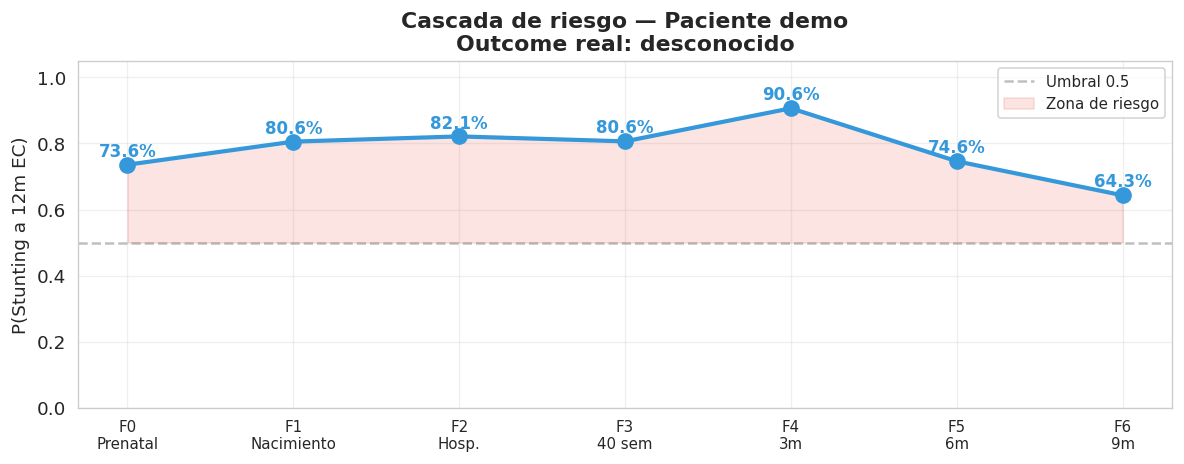


=== DEMO 3: Paciente nuevo con solo datos de nacimiento ===
PREDICCIÓN DE RIESGO — Stunting a 12 meses EC
  Fase evaluada   : F1_Nacimiento
  Probabilidad    : 71.4%
  Clasificación   : RIESGO  (umbral=50%)
  Features usadas : 3 / 77
  Features faltantes (74): ['CSP_SituaPareja', 'CSP_TipoVivienda', 'CSP_EscolaridadMadre', 'CSP_SituacionLaboralMadre', 'CSP_EscolaridadPadre']...
  Features nuevas ignoradas (2): ['ERN_EdadGestacional', 'CP_Embarazos']


In [58]:
# --- Demo 1: paciente real del dataset (tomado por índice) ---
paciente_real = df.iloc[42].to_dict()

print('=== DEMO 1: Paciente real del dataset ===')
for fase_demo in ['F1_Nacimiento', 'F2_Hospitalizacion', 'F4_3meses', 'F6_9meses']:
    res = predecir_riesgo(paciente_real, fase=fase_demo, outcome='Stunting', verbose=False)
    print(f'  {fase_demo:<22}: P={res["probabilidad"]:.1%}  → {res["clasificacion"]}')

# Verificar outcome real
outcome_real = paciente_real.get('stunting12m')
print(f'\n  Outcome real (stunting12m): {"STUNTED" if outcome_real == 1 else "NO stunted" if outcome_real == 0 else "desconocido"}')

# --- Demo 2: predicción en cascada completa con gráfica ---
print('\n=== DEMO 2: Cascada de riesgo para el mismo paciente ===')
fases_cascade = [f for f in FASE_ORDER
                 if os.path.exists(f'modelos_pmci/modelo_Stunting_{f}.lgb')]
probs_cascade  = []

for fase_c in fases_cascade:
    res = predecir_riesgo(paciente_real, fase=fase_c, outcome='Stunting', verbose=False)
    probs_cascade.append(res['probabilidad'])
    print(f'  {fase_c:<22}: {res["probabilidad"]:.1%}')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(fases_cascade))
color_line = '#e74c3c' if (outcome_real == 1) else '#3498db'
ax.plot(x, probs_cascade, marker='o', linewidth=2.5, markersize=9, color=color_line)
for xi, p in zip(x, probs_cascade):
    ax.text(xi, p + 0.025, f'{p:.1%}', ha='center', fontsize=10, fontweight='bold', color=color_line)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.5')
ax.fill_between(x, 0.5, probs_cascade,
                where=[p >= 0.5 for p in probs_cascade],
                alpha=0.15, color='#e74c3c', label='Zona de riesgo')
ax.set_xticks(x)
ax.set_xticklabels([fase_labels_short[f] for f in fases_cascade], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('P(Stunting a 12m EC)')
ax.set_title(f'Cascada de riesgo — Paciente demo\n'
             f'Outcome real: {"STUNTED" if outcome_real==1 else "NO stunted" if outcome_real==0 else "desconocido"}',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Demo 3: paciente con solo variables de nacimiento (F1) ---
print('\n=== DEMO 3: Paciente nuevo con solo datos de nacimiento ===')
paciente_nuevo = {
    'CP_TallaMadre':    158.0,
    'ERN_Peso':         1050.0,   # peso al nacer (gramos)
    'ERN_Talla':        35.0,     # talla al nacer (cm)
    'ERN_EdadGestacional': 28,    # semanas de gestación
    'CP_Embarazos':     2,
}
res_nuevo = predecir_riesgo(paciente_nuevo, fase='F1_Nacimiento', outcome='Stunting')